In [4]:
import numpy as np
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15 
import os 
import ytree 
import multiprocessing 
from functools import partial

In [5]:
%matplotlib inline

# from sapphire.read_trees import read_tng, interpolate_trees
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def mass_field(field, data):
    # data.arbor points to the parent Arbor
    return data["mvir"]

def read_trees(parameters):
    
    # parse the parameters dict for parameters we need 
    tree_path = parameters['tree_path'] # *absolute* path to directory containing isotree_$subvolume.dat files 
    subvolumes = parameters['subvolumes'] # list of isotree suffixes for individual subvolumes, e.g., ['0_0_0','0_1_0','2_3_4']
    min_root_mass = parameters['min_root_mass'] # minimum root (z=0) halo mass in units of Msun (no little-h)
    num_readers = parameters['num_readers'] # number of tree files (subvolumes) to read in parallel

    # set up multiprocessing for reading trees in parallel or serial (latter if num_readers=1)
    pool = multiprocessing.Pool(processes=num_readers) 

    # create a functools.partial object where tree_path and min_root_mass are fixed and only subvolume varies between pool map calls
    pool_reader = partial(read_single_subvolume,tree_path=tree_path,min_root_mass=min_root_mass)
    
    # map the read_single_halo function to each pair of (halo_name,tree_path) in parallel
    out = pool.map(pool_reader,subvolumes)

    # close pool processes to free memory
    pool.close()
    pool.join()            
    
    # use dict comprehension to merge the ID:table pairs of all halos from all subvolumes into a single huge dictionary
    tables_tng = {key:value for d in out for key,value in d.items()}        

    return tables_tng

In [7]:
def read_single_subvolume(subvolume,tree_path,min_root_mass):
    """
    This reads in and returns data in required format for a single TNG subvolume.
    
    subvolume is a single string denoting the subvolume suffix of the isotree file, e.g., '0_0_0'
    tree_path is the *absolute* path to the directory containing the isotree_$subvolume.dat files
    min_root_mass is the minimum root halo mass in Msun below above which halos will be included
    
    Generally you want min_root_mass ~ 1000 * DM resolution so it has a sufficient number of (lower mass) progenitors
    """
    
    print('Reading in trees for subvolume=%s'%subvolume,flush=True)
    
    # use ytree to read in this file 
    a = ytree.load(os.path.join(tree_path,'isotree_%s.dat'%subvolume))
    
    a.add_derived_field("mass", mass_field, units="Msun/h")
    
    
    # create list of root halo IDs for all halos satisfying min root mass cut 
    trees_rootID = [t['Tree_root_ID'] for t in a if t['mvir']/Planck15.h > min_root_mass] 
    
    # construct a column where all values are the subvolume string that this halo belongs to
    trees_subvolume = np.full(len(trees_rootID),subvolume)    
    
    # now create list of lists with required progenitor property time series for each halo
    # NOTE: this is only for the most massive progenitor lineage ordered from high-z to low-z
    # NOTE: Mvir and Rvir are read as float32 by default but must be float64 otherwise Vvir can become inf due to overflow [ytree bug?]
    trees_haloID = [t['prog','id'][::-1] for t in a if t['mvir']/Planck15.h > min_root_mass] # unique halo ID across whole simulation
    trees_redshift = [t['prog','redshift'][::-1] for t in a if t['mvir']/Planck15.h > min_root_mass] # dimensionless
    trees_Mvir = [np.array(t['prog','mvir'],dtype=np.float64)[::-1]/Planck15.h for t in a if t['mvir']/Planck15.h > min_root_mass] # Msun
    trees_Rvir = [np.array(t['prog','scale']*t['prog','rvir'],dtype=np.float64)[::-1]/Planck15.h for t in a if t['mvir']/Planck15.h > min_root_mass] # proper kpc
    trees_cNFW = [np.array(t['prog','rvir']/t['prog','Rs_Klypin'])[::-1] for t in a if t['mvir']/Planck15.h > min_root_mass] # dimensionless
    trees_Spin = [t['prog','Spin'][::-1] for t in a if t['mvir']/Planck15.h > min_root_mass] # dimensionless

    # convert redshift to cosmic age (time since BB) in Gyr for the ODE solver 
    trees_age = [Planck15.age(t_z).value for t_z in trees_redshift]
    
    # compute Vvir from sqrt(GMvir/Rvir) in proper km/s
    trees_Vvir = [np.sqrt(G*t_Mvir*Msun_to_g / (t_Rvir*kpc_to_cm))*1e-5 for (t_Mvir,t_Rvir) in zip(trees_Mvir,trees_Rvir)]   
    
    # use finite differencing of Mvir time series to compute net halo DM accretion rate 
    # NOTE: this pads the differenced arrays to be same length as original arrays, then clips rates to some small number > 0 Msun/yr so we can take log10 during interpolation
    trees_MAH = [np.clip(np.append(np.diff(t_Mvir) / np.diff(t_Time*1e9), 0),1e-10,None) for (t_Mvir,t_Time) in zip(trees_Mvir,trees_age)]
    
    # loop over every root halo ID, construct its minimal astropy table, and add it to a dict indexed by the root halo ID
    # NOTE: the column names MUST be what is expected from the other sapphire modules and log10 must be taken where expected 
    tables_tng = {} 
    
    for rootnum,rootID in enumerate(trees_rootID): 
        
        # do not include if the halo is included in < half TNG output snapshots -- these appear to be artifact halos losing mass that are found only at low-z
        if len(trees_haloID[rootnum]) < 50: 
            continue
        
        tables_tng[rootID] = Table([trees_haloID[rootnum],
                                   np.full(len(trees_haloID[rootnum]),rootID),
                                   np.full(len(trees_haloID[rootnum]),trees_subvolume[rootnum]),
                                   trees_redshift[rootnum],
                                   trees_age[rootnum],
                                   np.log10(trees_Mvir[rootnum]),
                                   np.log10(trees_Rvir[rootnum]),
                                   np.log10(trees_cNFW[rootnum]),
                                   np.log10(trees_Vvir[rootnum]),
                                   trees_Spin[rootnum],
                                   trees_MAH[rootnum]],
                                   names=('haloID','root_haloID','subvolume','redshift','cosmic_age','log_mvir','log_rvir','log_cNFW','log_vvir', 'Spin', 'dm_accretion_rate',))
        
    return tables_tng 


In [8]:
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
Msun_to_g = u.Msun.to('g')
G = const.G.to('cm**3 / (g * s**2)').value

In [524]:
parameters = {'output_path':'./', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care of writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/Users/austen/data/GUREFT90_isotrees/', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':['0_0_0'],
              'num_readers':1,
              'min_root_mass':2.5e10} # relevant for TNG, not for FIRE

In [525]:
halos = read_single_subvolume('0_0_0', tree_path=parameters['tree_path'],
                      min_root_mass=parameters['min_root_mass'])

Reading in trees for subvolume=0_0_0


Loading tree roots: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13551491643/13551491643 [00:21<00:00, 635143797.53it/s]


In [526]:
# load modules
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15, FlatLambdaCDM
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from scipy.interpolate import RegularGridInterpolator, UnivariateSpline, InterpolatedUnivariateSpline, interp2d, RectBivariateSpline

from scipy.ndimage import gaussian_filter1d
from glob import glob
import multiprocessing
from scipy.integrate import simps, solve_ivp, trapz
import h5py 
from timeit import default_timer as timer
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [527]:
###### UV background suppression of fb*Mdot_vir (relevant for m10 halos)

# First compute the "Filtering Mass" at which halos accrete only half of the incoming baryon fraction fb*Mdot_vir (Gnedin+00)
# The following is basically copied from Rachel's SAM code (module = stars.cc)
# This is the analytic model from Appendix B of Kravtsov+04

def m_filt(z, z_overlap=9.0, z_reionize=3.5, z_squelch=8.0):
    # from Rachel's param.sample, follows Kravtsov+04 appendix B
    # z1=z_overlap, z2=z_reionize, z_squelch = when suppression ('squelching') turned on
    # Rachel tuned these parameters to reproduce Okamoto+08, so do not over-interpret parameter names or modify values
    # NOTE: I should probably re-write this so the parameters reflect their intended meaning (eg z_reionize >> 3.5)
    
    a_o = 1.0/(1+z_overlap) # scale factor where multiple HII regions BEGIN TO overlap
    a_r = 1.0/(1+z_reionize) # scale factor of complete reionization
    a = 1.0 / (1+z) # current scale factor
    
    # Jeans mass in Msun; 0.59 is mean molecular weight
    m_jeans = 2.5E11 * Planck15.h**-1 * np.sqrt(Planck15.Om0)**-1 * (0.59)**-1.5 
    
    alpha = 6.0 # power that controls growth rate of UV background flux (Kravtsov+04 fixed alpha=6)
    
    if a < a_o:
        f_a = (3.0 * a / ((2.0+alpha)*(5.0+2.0*alpha))) * (a/a_o)**alpha
    elif a >= a_o and a <= a_r: 
        f_a = (3.0/a)*a_o**2*(1.0/(2+alpha) - (2*(a/a_o)**-0.5)/(5+2*alpha)) + a**2/10. - (a_o**2/10.)*(5-4*(a/a_o)**-0.5)
    elif a > a_r: 
        f1 = a_o**2*(1/(2+alpha) - 2*(a/a_o)**-0.5/(5+2*alpha))
        f2 = a_r**2/10.*(5-4*(a/a_r)**-0.5)
        f3 = a_o**2/10.*(5-4*(a/a_o)**-0.5)
        f4 = a*a_r/3. - a_r**2/3.*(3-2*(a/a_r)**-0.5)
        f_a = 3.0/a * (f1 + f2 - f3 + f4)
        
    mf = m_jeans * f_a**1.5
    
    # constant from Rachel's stars.cc implementation
    # this ensures Mfilt defined in this way matches the Okamoto+08 "M_characteristic" definition normalization
    Mfilt_factor = 0.0933 
    
    return Mfilt_factor * mf

# Next compute the actual suppression factor f_UV that depends on the filtering mass 
# Halos with Mvir >> Mfilt will have f_UV ~ 1 (no suppression), whereas much lower mass halos tend to f_UV ~ 0
# This is eqn (1) of Okamoto+08 who studied the UV background in hydro simulations
# NOTE: I should update this to use Faucher-Giguere+09 (or 18) to be consistent with FIRE
def collapse_fraction(m,mfilt):
    alpha = 2.0
    
    fcoll = (1+(2**(alpha/3.)-1.)*(m/mfilt)**-alpha)**(-3/alpha)
    
    return fcoll

In [528]:
""" interpolate sutherland & dopita 93 CIE cooling function """

# read the cooling table
# rows = temperature, columns = gas metallicities log(Z/Zsun), units = erg cm^3 / s
tcool = Table.read('../dev/newcool.dat',format='ascii',
                   names=('logT','-99','-3','-2','-1.5','-1.0','-0.5','0.0','0.5',))
# first convert tcool astropy Table into a 2D numpy array (this is the most elegant, easiest way I found to do this)
# NOTE: I omitted logZ=-99 to make interpolation easier since logZ=-99 (metal-free) is similar to logZ=-3 (extremely metal-poor)
arr_coolfunc = tcool.to_pandas().to_numpy(dtype='float')[:,2:]
# set up the (logT, logZ) meshgrid corresponding to each point in the 2D cooling function array
logT_bins = np.asarray(tcool['logT'])
logZ_bins = np.array(tcool.colnames[2:],dtype='float')
logT_mesh, logZ_mesh = np.meshgrid(logT_bins, logZ_bins) # for scatter plot 

# create linear 2D interpolator function (use 'nearest neighbor' extrapolation outside input range)
coolfunc_sd93 = interp2d(logT_bins, logZ_bins, arr_coolfunc.T, kind='linear', fill_value=None) 

# this seems better behaved for pairs (logT,logZ)
rgi_sd93 = RegularGridInterpolator((logT_bins,logZ_bins),arr_coolfunc,method='nearest',bounds_error=False,fill_value=None)

### test evaluation for a given (logT, logZcgm)
coolfunc_sd93(6.0,-1.0),rgi_sd93((6.0,-1.0)) # Lambda in erg*cm**3/s for CGM that has T=1e6 K and Zcgm=0.1Zsun everywhere

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2628088492.py:16: DeprecationWarning: `interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff`

  coolfunc_sd93 = interp2d(logT_bins, logZ_bins, arr_coolfunc.T, kind='linear', fill_value=None)
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2628088492.py:22: DeprecationWarning:         `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `Re

(array([-22.59]), array(-22.59))

In [529]:
"""
Fitting functions for free model parameters.
These are power laws where both the normalization and slope can depend on redshift.
The default values are motivated by Pandya+22 but they are designed to be varied. 
"""

def get_tdep(Vvir,redshift,A=3.0,alpha0=-3.0,alphaz=0.0,beta=-0.7): 
    """
    Returns ISM gas depletion time in Gyr for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """
    alpha = alpha0 + alphaz*(1+redshift) 
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaM_ism(Vvir,redshift,A=1.0,alpha0=-3.7,alphaz=0.0,beta=2.4):
    """
    Returns ISM mass loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """    
    alpha = alpha0 + alphaz*(1+redshift)
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaE_ism(Vvir,redshift,A=0.1,alpha0=-0.5,alphaz=0.0,beta=0.0): # March 2023 -- this is not designed to be consistent with get_vB_ism
    """
    Returns ISM energy loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaE to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    alpha = alpha0 + alphaz*(1+redshift)
    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0])

def get_etaZ_ism(Vvir,redshift,A=0.5,alpha0=0.0,alphaz=0.0,beta=0.0): # this is the Carr/Bryan approach for increasing Zwind > Zism 
    """
    Returns ISM metal loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless] 
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaZ to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    
    alpha = alpha0 + alphaz*(1+redshift)
    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0])    
    

def get_Zin_halo(Vvir,redshift,A=0.25,alpha0=2.2,alphaz=0.0,beta=-1.3):
    """
    Returns metal mass fraction of inflowing gas at Rvir for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    NOTE: we multiply the return value by 0.02 since the fiducial FIRE-2 calibrated parameters give Zin_halo in units of Zsun=0.02
    """      
    alpha = alpha0 + alphaz*(1+redshift)
    return 0.02 * A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_fprev(Vvir,fmin=0.25,fmax=0.9641,fscale=-7.1348,fpivot=1.8775):
    """
    Returns halo gas accretion suppression factor [dimensionless] for halo with Vvir [km/s]
    Generalized logistic function
    """      
    return fmin + (fmax - fmin) / (1.0 + np.exp(fscale*(np.log10(Vvir) - fpivot)))    
    

In [530]:
def analytic_n0(Mcgm,Rvir,alpha_n):
    Rvir = Rvir * kpc_to_cm
    return (3+alpha_n)*Mcgm*Rvir**(alpha_n) / (4*np.pi * 0.59*const_mp * (Rvir**(3+alpha_n) - (0.1*Rvir)**(3+alpha_n))) # cm**-3

def analytic_T0(Ecgm,Rvir,n0,alpha_n,alpha_T):
    Rvir = Rvir * kpc_to_cm
    T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(0.1*Rvir)**(alpha_n+alpha_T+3))) # K
    # return np.nan_to_num(T0_est,nan=1,posinf=1,neginf=1) # at early times when Mcgm=0, n0=0 so T0=nan; return 1K
    return T0_est

In [531]:
### define constants and conversions 
const_mp = const.m_p.to('Msun').value 
cm_to_kpc = u.cm.to('kpc') # multiply something in cm by this to get to kpc 
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
const_kB = const.k_B.to('erg/K').value # so that k*T = erg by default
yr_to_s = u.yr.to('s') # if you multiply something in yr by this, you get it in units of sec
s_to_yr = u.s.to('yr')
Msun_to_g = u.Msun.to('g') 
f_b = Planck15.Ob0 / Planck15.Om0 # ~15 %
G = const.G.to('cm**3 / (g * s**2)').value

In [532]:
kpc_to_cm = 3.086e21
cm_to_kpc = kpc_to_cm**-1

pc_to_cm = kpc_to_cm / 1e3
cm_to_pc = pc_to_cm**-1

km_to_cm = 1e5
cm_to_km = km_to_cm**-1

msun_to_g = 1.988e33 
g_to_msun = msun_to_g**-1

yr_to_s = 3.154e7 
s_to_yr = yr_to_s**-1

G = 6.674e-8 # dyne^2 cm gram^-2 

k_B = 1.381e-16 # ergs per kelvin

In [1230]:
"""
Set up the integrator function 
This should return the Mdot's at each timestep
"""

def integrator(logt, logy, parameters, interpolators):
    interp_redshift = interpolators[0]
    interp_logMAH = interpolators[1]
    interp_logSpin = interpolators[2]
    interp_logMvir = interpolators[3]
                      
    interp_logRvir = interpolators[4]
    interp_logVvir = interpolators[5]
    interp_logcNFW = interpolators[6]
    
    # unpack the log10 state variables and raise to power 10 
    M_star = 10**logy[0]
    M_ism = 10**logy[1]
    M_cgm = 10**logy[2]
    Eth_cgm = 10**logy[3]
    MZ_star = 10**logy[4]
    MZ_ism = 10**logy[5]
    MZ_cgm = 10**logy[6]
    
    # also raise the log10(t/sec) to power of 10 and convert to Gyr for interpolation functions
    t_Gyr = 10**logt * s_to_yr * 1e-9 
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    etaM_A = parameters['etaM_A']
    etaM_alpha0 = parameters['etaM_alpha0']
    etaM_alphaz = parameters['etaM_alphaz']
    etaM_beta = parameters['etaM_beta']    
    tdep_A = parameters['tdep_A']
    tdep_alpha0 = parameters['tdep_alpha0']   
    tdep_alphaz = parameters['tdep_alphaz']   
    tdep_beta = parameters['tdep_beta']    
    etaE_A = parameters['etaE_A']
    etaE_alpha0 = parameters['etaE_alpha0']
    etaZ_A = parameters['etaZ_A']
    
    etaZ_alpha0 = parameters['etaZ_alpha0']
    etaZ_alphaz = parameters['etaZ_alphaz']
    etaZ_beta = parameters['etaZ_beta']    
    alpha_prev = parameters['alpha_prev'] 
    return_all = parameters['return_all']
    
    # get Mdot_in_dm, Vvir and other quantities at this time using my interpolator functions 
    # I do .item() since scipy returns 0d array instead of scalar because of some convention ... 
    redshift = interp_redshift(t_Gyr).item() # dimensionless    
    Mdot_in_dm = 10**interp_logMAH(t_Gyr).item() # Msun/yr 
    Mvir = 10**interp_logMvir(t_Gyr).item() # Msun
    Rvir = 10**interp_logRvir(t_Gyr).item() # proper kpc
    Vvir = 10**interp_logVvir(t_Gyr).item() # proper km/s
    NFW_c = 10**interp_logcNFW(t_Gyr).item() # dimensionless NFW halo concentration = Rvir/Rs_klypin
    Spin = 10**interp_logSpin(t_Gyr).item() # dimensionless spin 
    
    # compute gas free-fall radius rff = radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir, redshift, A=tdep_A, alpha0=tdep_alpha0, alphaz=tdep_alphaz, beta=tdep_beta) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift,A=etaM_A,alpha0=etaM_alpha0,alphaz=etaM_alphaz,beta=etaM_beta) # dimensionless
    etaE_ism = get_etaE_ism(Vvir,redshift,A=etaE_A,alpha0=etaE_alpha0,alphaz=0.0,beta=0.0) # dimensionless    
    etaZ_ism = get_etaZ_ism(Vvir,redshift,A=etaZ_A,alpha0=etaZ_alpha0,alphaz=etaZ_alphaz,beta=etaZ_beta) # dimensionless    

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_in_dm # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1),np.log10(1.0),100)    

    n0_val = analytic_n0(M_cgm,Rvir,alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm,Rvir,n0_val,alpha_n,alpha_T) # K
    
    # now construct density and temperature profiles
    n_rarr = n0_val * rarr**alpha_n # cm**-3        
    T_rarr = T0_val * rarr**alpha_T # K
    
    halo_coolfunc = 10**rgi_sd93((np.log10(T0_val), log_Zcgm))
    # print('coolfunc=%s, T0_val=%s'%(halo_coolfunc,T0_val))

    r_disk_gas = (2 * Spin * Rvir) * kpc_to_cm 
    r_disk_star = r_disk_gas / 1.59 
    
    Sig_star = M_star * Msun_to_g / (2. * np.pi * r_disk_star**2) # g cm^-2
    Sig_gas = M_ism * Msun_to_g / (2. * np.pi * r_disk_gas**2) # g cm^-2 
    
    # compute the Edot_cool integral in erg/s
    # NOTE: this needs to be a list comprehension since integration of radial profiles happens for each halo
    Edot_cool = trapz(y=4*np.pi*(rarr*Rvir*kpc_to_cm)**2*(n_rarr)**2*halo_coolfunc,x=rarr*Rvir*kpc_to_cm) 
    
    # limit catastrophic cooling by taking minimum of Edot_cool and Eth/tff since CGM cannot lose energy faster than grav collapse (radiating away grav PE)
    # NOTE: added axis=0 for np.min over subhalo array
    Edot_cool = np.min([Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)], axis=0)
     

    # compute an effective tcool as Energy_cgm / Edot_cool
    tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr    

    # compute effective free-fall time at pre-defined radius rff 
    tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / NFW_vcirc)*s_to_yr*1e-9 # Gyr        

    # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
    t_accrete = tcool_eff + tff_eff # Gyr
    Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr    
    
    
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism * 1e9) # Msun/yr
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    
    # March 2023 -- switch from parameterized vB back to parameterized etaE for computing Edot_wind 
    Edot_wind = etaE_ism * ((1e51/100.) * (Mdot_sfr/yr_to_s)) # erg/s
        
    ####### At z>8.989, no cooling tables so Mdot_cool = 0 hence M_ism can become negative (SFR still gets calculated e Mism/tdep)
    ## set Mdot_sfr = 0 and Mdot_wind = 0 otherwise ODE solver will try to accommodate this with crazy small timesteps
    # another hack: also enforce this when Mism < 1e3 and Mdot_cool=0.0 which happens at early times in the dwarfs
    # if redshift > 8.989 or (M_ism < 1e3 and Mdot_cool == 0.0): 
    #     Mdot_sfr = 0.0
    #     Mdot_wind = 0.0
    #     etaE_ism = 0.0
    
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
    Edot_out_halo = np.max([0.0,Delta_Ecgm]) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    # f_prev = np.min([1.0,kappa_heat * (Edot_out_halo / Edot_in_halo)])
    
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    # Carr+23/Pandya+20 style version where f_prev depends on ratio of Edot_out_halo and Edot_in_halo in the absence of preventative feedback
    # f_prev = np.min([alpha_prev * Edot_in_halo/Edot_out_halo, 1.0])
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev 
        
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # FIRST: since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind) / yr_to_s # Msun/s 
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo) / yr_to_s # Msun/s 
    Edot_cgm_th = Edot_in_halo - Edot_cool + Edot_wind - Edot_out_halo # erg/s
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo) / yr_to_s # Msun/s
    
    # print(Mdot_sfr_longlived)
    # SECOND: since we are integrating log(state_variable) AND log(time), multiply RHS by 10**t[sec] / 10**state_variable
    #         thus these all become dimensionless logarithmic derivatives dlogX/dlogt
    Mdot_sfr_longlived *= 10**logt / M_star 
    Mdot_ism *= 10**logt / M_ism 
    Mdot_cgm *= 10**logt / M_cgm
    Edot_cgm_th *= 10**logt / Eth_cgm
    MZdot_star *= 10**logt / MZ_star
    MZdot_ism *= 10**logt / MZ_ism
    MZdot_cgm *= 10**logt / MZ_cgm    
    

    if return_all is True:

        return {'cosmic_age':t_Gyr, 'redshift':redshift, 'Mvir': Mvir, 'Rvir': Rvir, 
                'T0_val': T0_val, 'n0_val': n0_val, 'Mfilt': Mfilt, 
                'M_star': M_star, 'Mdot_sfr_longlived': Mdot_sfr_longlived / 10**logt * M_star / s_to_yr, 
                'Spin': Spin, 
                't_accrete': t_accrete, 'tdyn_halo': tdyn_halo, 'tff_eff': tff_eff, 'tcool_eff': tcool_eff,
                'MZ_star': MZ_star, 'MZdot_star': MZdot_star, 'Eth_cgm': Eth_cgm, 'Edot_cgm_th': Edot_cgm_th, 
                'M_ism': M_ism, 'Sig_star': Sig_star, 'Sig_gas': Sig_gas, 
                'Mdot_ism': Mdot_ism  / 10**logt * M_ism / s_to_yr, 
                'Edot_cgm_th': Edot_cgm_th / 10**logt * Eth_cgm ,
                'M_cgm': M_cgm, 'Mdot_cgm': Mdot_cgm,
                'MZ_ism': MZ_ism, 'MZdot_ism': MZdot_ism, 'MZ_cgm': MZ_cgm, 'MZdot_cgm': MZdot_cgm,
                'Mdot_wind': Mdot_wind, 'Mdot_cool': Mdot_cool, 'Tvir': Tvir,
                'Mdot_in_halo':Mdot_in_halo, 'Mdot_out_halo': Mdot_out_halo, 
                'Edot_cool': Edot_cool, 'Edot_in_halo': Edot_in_halo, 
                'Edot_wind': Edot_wind, 'Edot_out_halo': Edot_out_halo, 'tdep_ism': tdep_ism} 
    else: 
        return [Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, MZdot_star, MZdot_ism, MZdot_cgm]

        

In [1087]:
def rho_nfw(mvir, rvir, c_nfw, r_disk):
    rho_halo = mvir / (4. / 3. * np.pi * rvir**3.)
    A_nfw = np.log(1. + c_nfw) - c_nfw / (1 + c_nfw)
    x = r_disk / rvir 

    return rho_halo / (3. * A_nfw * x * (c_nfw**-1. + x)**2.)

In [1088]:
# modified for sapphire. see rusty for 'full' notebook 
def calc_H_Wtot(Sig_star, Sig_gas, rho_dm_r, sig_eff, zeta_d=1/3):
 
    Omega_d_2 = 4. * np.pi * G * rho_dm_r 
    
    p1 = np.pi * G * (Sig_star + Sig_gas) 
    p2 = p1**2 + 8 * np.pi * zeta_d * (Omega_d_2) * sig_eff**2

    W = Sig_gas * (p1 + p2**(0.5)) / 4.
    
    H = 2. * sig_eff**2 / (p1 + p2**(0.5) )
    
    return H, W

In [1089]:
# modified for sapphire. see rusty for 'full' notebook 
def opt_sig_eff(Sig_star, Sig_gas, rho_dm_r, sig_eff, zeta_d=1/3): 

    _, W = calc_H_Wtot(Sig_star, Sig_gas, rho_dm_r, sig_eff, zeta_d)

    W_4 = W / (1e4 * k_B)
    
    sig_guess = 12. * W_4**(0.22)

    return sig_guess

In [1229]:
"""
Set up the integrator function 
This should return the Mdot's at each timestep
"""

def integrator_PRFM(logt, logy, parameters, interpolators):
    interp_redshift = interpolators[0]
    interp_logMAH = interpolators[1]
    interp_logSpin = interpolators[2]
    interp_logMvir = interpolators[3]
                      
    interp_logRvir = interpolators[4]
    interp_logVvir = interpolators[5]
    interp_logcNFW = interpolators[6]
    
    # unpack the log10 state variables and raise to power 10 
    M_star = 10**logy[0]
    M_ism = 10**logy[1]
    M_cgm = 10**logy[2]
    Eth_cgm = 10**logy[3]
    MZ_star = 10**logy[4]
    MZ_ism = 10**logy[5]
    MZ_cgm = 10**logy[6]
    
    # also raise the log10(t/sec) to power of 10 and convert to Gyr for interpolation functions
    t_Gyr = 10**logt * s_to_yr * 1e-9 
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    etaM_A = parameters['etaM_A']
    etaM_alpha0 = parameters['etaM_alpha0']
    etaM_alphaz = parameters['etaM_alphaz']
    etaM_beta = parameters['etaM_beta']    
    tdep_A = parameters['tdep_A']
    tdep_alpha0 = parameters['tdep_alpha0']   
    tdep_alphaz = parameters['tdep_alphaz']   
    tdep_beta = parameters['tdep_beta']    
    etaE_A = parameters['etaE_A']
    etaE_alpha0 = parameters['etaE_alpha0']
    etaZ_A = parameters['etaZ_A']
    
    etaZ_alpha0 = parameters['etaZ_alpha0']
    etaZ_alphaz = parameters['etaZ_alphaz']
    etaZ_beta = parameters['etaZ_beta']    
    alpha_prev = parameters['alpha_prev'] 
    return_all = parameters['return_all']
    
    
    
    # get Mdot_in_dm, Vvir and other quantities at this time using my interpolator functions 
    # I do .item() since scipy returns 0d array instead of scalar because of some convention ... 
    redshift = interp_redshift(t_Gyr).item() # dimensionless    
    Mdot_in_dm = 10**interp_logMAH(t_Gyr).item() # Msun/yr 
    Mvir = 10**interp_logMvir(t_Gyr).item() # Msun
    Rvir = 10**interp_logRvir(t_Gyr).item() # proper kpc
    Vvir = 10**interp_logVvir(t_Gyr).item() # proper km/s
    NFW_c = 10**interp_logcNFW(t_Gyr).item() # dimensionless NFW halo concentration = Rvir/Rs_klypin
    Spin = 10**interp_logSpin(t_Gyr).item() # dimensionless spin 
    
    # compute gas free-fall radius rff = radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir,redshift,A=tdep_A,alpha0=tdep_alpha0,alphaz=tdep_alphaz,beta=tdep_beta) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift,A=etaM_A,alpha0=etaM_alpha0,alphaz=etaM_alphaz,beta=etaM_beta) # dimensionless
    etaE_ism = get_etaE_ism(Vvir,redshift,A=etaE_A,alpha0=etaE_alpha0,alphaz=0.0,beta=0.0) # dimensionless    
    etaZ_ism = get_etaZ_ism(Vvir,redshift,A=etaZ_A,alpha0=etaZ_alpha0,alphaz=etaZ_alphaz,beta=etaZ_beta) # dimensionless    

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_in_dm # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1),np.log10(1.0),100)    

    n0_val = analytic_n0(M_cgm,Rvir,alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm,Rvir,n0_val,alpha_n,alpha_T) # K
    
    # now construct density and temperature profiles
    n_rarr = n0_val * rarr**alpha_n # cm**-3        
    T_rarr = T0_val * rarr**alpha_T # K
    
    halo_coolfunc = 10**rgi_sd93((np.log10(T0_val), log_Zcgm))
    # print('coolfunc=%s, T0_val=%s'%(halo_coolfunc,T0_val))
    
    # compute the Edot_cool integral in erg/s
    # NOTE: this needs to be a list comprehension since integration of radial profiles happens for each halo
    Edot_cool = trapz(y=4*np.pi*(rarr*Rvir*kpc_to_cm)**2*(n_rarr)**2*halo_coolfunc,x=rarr*Rvir*kpc_to_cm) 
    
    # limit catastrophic cooling by taking minimum of Edot_cool and Eth/tff since CGM cannot lose energy faster than grav collapse (radiating away grav PE)
    # NOTE: added axis=0 for np.min over subhalo array
    Edot_cool = np.min([Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)], axis=0)
     

    # compute an effective tcool as Energy_cgm / Edot_cool
    tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr    

    # compute effective free-fall time at pre-defined radius rff 
    tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / NFW_vcirc)*s_to_yr*1e-9 # Gyr        

    # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
    t_accrete = tcool_eff + tff_eff # Gyr
    Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr    
    
    ### PRFM BLOCK ### 
    ##################
    sig_e = 15. # km / s
    sig_old = 0.

    # solve at the gas disk's scale length ?
    
    r_disk_gas = (2 * Spin * Rvir) * kpc_to_cm 
    r_disk_star = (2 * Spin * Rvir) * kpc_to_cm  / 1.59 
    
    Sig_star = M_star * Msun_to_g / (2. * np.pi * r_disk_star**2) # g cm^-2
    Sig_gas = M_ism * Msun_to_g / (2. * np.pi * r_disk_gas**2) # g cm^-2 

    rho_dm_r = rho_nfw(Mvir * Msun_to_g, Rvir * kpc_to_cm, NFW_c, r_disk_gas) # rho_halo / (3 * A_nfw * x * (c_nfw**-1 + x)**2)

    # how many iterations to converge sig_eff
    n_iter = 0 
    # if sig is in km, error is down to ~m precision 
    while ((abs(sig_old - sig_e) / sig_e) > 1e-4):
        sig_old = np.copy(sig_e)
        sig_e = opt_sig_eff(Sig_star, Sig_gas, rho_dm_r, sig_e * km_to_cm)
        n_iter = n_iter + 1 
                
    # get final H, W with converged sig_eff 
    H, W = calc_H_Wtot(Sig_star, Sig_gas, rho_dm_r, sig_e * km_to_cm) # cm, cm

    # feedback yield 
    Up_tot = 10.**(-0.212 * np.log10(W / k_B) + 3.86) * km_to_cm # km s^-1 to cm s-1

    # dynamical time 
    t_dyn = 2. * H / (sig_e * km_to_cm) # s 

    # depletion time 
    tdep_ism = Up_tot * t_dyn / (sig_e * km_to_cm) * s_to_yr * 1e-9 # s to Gyr
    
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism * 1e9) # Msun/yr
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    
    # March 2023 -- switch from parameterized vB back to parameterized etaE for computing Edot_wind 
    Edot_wind = etaE_ism * ((1e51/100.) * (Mdot_sfr/yr_to_s)) # erg/s
        
    ####### At z>8.989, no cooling tables so Mdot_cool = 0 hence M_ism can become negative (SFR still gets calculated e Mism/tdep)
    ## set Mdot_sfr = 0 and Mdot_wind = 0 otherwise ODE solver will try to accommodate this with crazy small timesteps
    # another hack: also enforce this when Mism < 1e3 and Mdot_cool=0.0 which happens at early times in the dwarfs
    # if redshift > 8.989 or (M_ism < 1e3 and Mdot_cool == 0.0): 
    #     Mdot_sfr = 0.0
    #     Mdot_wind = 0.0
    #     etaE_ism = 0.0
    
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
    Edot_out_halo = np.max([0.0,Delta_Ecgm]) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    # f_prev = np.min([1.0,kappa_heat * (Edot_out_halo / Edot_in_halo)])
    
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    # Carr+23/Pandya+20 style version where f_prev depends on ratio of Edot_out_halo and Edot_in_halo in the absence of preventative feedback
    # f_prev = np.min([alpha_prev * Edot_in_halo/Edot_out_halo, 1.0])
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev 
        
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # FIRST: since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind) / yr_to_s # Msun/s 
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo) / yr_to_s # Msun/s 
    Edot_cgm_th = Edot_in_halo - Edot_cool + Edot_wind - Edot_out_halo # erg/s
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo) / yr_to_s # Msun/s
    
    # print(Mdot_sfr_longlived)
    # SECOND: since we are integrating log(state_variable) AND log(time), multiply RHS by 10**t[sec] / 10**state_variable
    #         thus these all become dimensionless logarithmic derivatives dlogX/dlogt
    Mdot_sfr_longlived *= 10**logt / M_star 
    Mdot_ism *= 10**logt / M_ism 
    Mdot_cgm *= 10**logt / M_cgm
    Edot_cgm_th *= 10**logt / Eth_cgm
    MZdot_star *= 10**logt / MZ_star
    MZdot_ism *= 10**logt / MZ_ism
    MZdot_cgm *= 10**logt / MZ_cgm    
    
#     print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    
#     print('M_star=%s,M_ism=%s,M_cgm=%s,Eth_cgm=%s,Ekin_cgm=%s,MZ_star=%s,MZ_ism=%s,MZ_cgm=%s'%(logy[0],logy[1],logy[2],logy[3],logy[4],logy[5],logy[6],logy[7]))    
    
#     print('Mdot_sfr_longlived=%s,Mdot_ism=%s,Mdot_cgm=%s,Edot_cgm_th=%s,Edot_cgm_kin=%s,MZdot_star=%s,MZdot_ism=%s,MZdot_cgm=%s'%(Mdot_sfr_longlived,Mdot_ism,
#                                                                                                                                   Mdot_cgm,Edot_cgm_th,Edot_cgm_kin,
#                                                                                                                                   MZdot_star,MZdot_ism,MZdot_cgm))
    
#     print('T0=%s,Edot_in_halo_th=%s,Edot_diss=%s,Edot_cool=%s,Edot_wind_th=%s,Edot_out_halo_th=%s'%(T0_val,
#                                                                                                     Edot_in_halo_th*10**logt / Eth_cgm,
#                                                                                                     Edot_diss*10**logt / Eth_cgm,
#                                                                                                     Edot_cool*10**logt / Eth_cgm,
#                                                                                                     Edot_wind_th*10**logt / Eth_cgm,
#                                                                                                     Edot_out_halo_th*10**logt / Eth_cgm))

    if return_all is True:

        return {'cosmic_age':t_Gyr, 'redshift':redshift, 'Mvir': Mvir, 'Rvir': Rvir, 
                'T0_val': T0_val, 'n0_val': n0_val, 'Mfilt': Mfilt, 
                'sig_e': sig_e, 'Up_tot': Up_tot * cm_to_km, 'W4': W  / k_B, 'r_disk_star': r_disk_star,
                'H': H, 'r_disk_gas': r_disk_gas, 
                'M_star': M_star, 'Mdot_sfr_longlived': Mdot_sfr_longlived / 10**logt * M_star / s_to_yr, 
                'n_iter': n_iter, 'Spin': Spin,
                't_accrete': t_accrete, 'tdyn_halo': tdyn_halo, 'tff_eff': tff_eff, 'tcool_eff': tcool_eff,
                'MZ_star': MZ_star, 'MZdot_star': MZdot_star, 'Eth_cgm': Eth_cgm,
                'Edot_cgm_th': Edot_cgm_th / 10**logt * Eth_cgm,
                'M_ism': M_ism, 'Sig_star': Sig_star, 'Sig_gas': Sig_gas, 
                'Mdot_ism': Mdot_ism  / 10**logt * M_ism / s_to_yr, 
                'M_cgm': M_cgm, 'Mdot_cgm': Mdot_cgm,
                'MZ_ism': MZ_ism, 'MZdot_ism': MZdot_ism, 'MZ_cgm': MZ_cgm, 'MZdot_cgm': MZdot_cgm,
                'Mdot_wind': Mdot_wind, 'Mdot_cool': Mdot_cool, 'Tvir': Tvir,
                'Mdot_in_halo':Mdot_in_halo, 'Mdot_out_halo': Mdot_out_halo, 
                'Edot_cool': Edot_cool, 'Edot_in_halo': Edot_in_halo, 
                'Edot_wind': Edot_wind, 'Edot_out_halo': Edot_out_halo, 'tdep_ism': tdep_ism, 
                't_dyn': t_dyn, 'Sig_star': Sig_star , 'Sig_gas': Sig_gas} 
    else: 
        return [Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, MZdot_star, MZdot_ism, MZdot_cgm]

        

In [1207]:
def get_interpolators(thalo):
    interp_redshift = InterpolatedUnivariateSpline(thalo['cosmic_age'],thalo['redshift'],
                                       k=3) # faster to interpolate than do cosmology root-finding calculation

    interp_logMAH = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                     np.log10(gaussian_filter1d(thalo['dm_accretion_rate'],10, mode='nearest')),
                                     k=3) # Msun/yr

    interp_logSpin = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                   gaussian_filter1d(np.log10(np.clip(thalo['Spin'], 0.005, np.inf)), 10, mode='nearest'),
                                   k=3) # dimensionless


    interp_logMvir = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                      gaussian_filter1d(thalo['log_mvir'],25,mode='nearest'),
                                      k=3) # Msun

    interp_logRvir = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                   gaussian_filter1d(np.log10(10**thalo['log_rvir']*(1/(1 + thalo['redshift']))),10,mode='nearest'),
                                   k=3) # proper kpc

    interp_logVvir = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                   gaussian_filter1d((thalo['log_vvir']),10,mode='nearest'),
                                   k=3) # proper km/s


    interp_logcNFW = InterpolatedUnivariateSpline(thalo['cosmic_age'],
                                   gaussian_filter1d((thalo['log_cNFW']), 25, mode='nearest'),
                                   k=3) # dimensionless
    
    return np.array([interp_redshift, interp_logMAH, interp_logSpin, interp_logMvir, 
                      interp_logRvir, interp_logVvir, interp_logcNFW] )


In [1208]:
def solve_system(i, parameters, ode_integrator):
    thalo = halos[i]
    
    # set up astropy cosmology object with same parameters as simulation
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.307, Ob0=0.049)

    ###### Set up interpolator functions called by the integrator to get Mdot_in_dm, Vvir, etc. at any time t
    # Apply 1D gaussian smoothing for noisy / discontinuous time series (otherwise Nth derivatives will explode)
    # and take log10 of properties that are guaranteed to be positive but huge OOM or sharp jumps (Mvir, Vvir, Rvir)

    tree_interpolators = get_interpolators(thalo)
    
    # set up range of integration times: from earliest redshift where we have Wiersma cooling func (z~8.98) to z=0 (t~13.79 Gyr)
    # LOGARITHMIC since we are integrating dlogX/dlogt 
    t_init = np.log10(Planck15.age(thalo['redshift'][0]).value * 1e9 * yr_to_s) # Gyr to sec
    t_final = np.log10(thalo['cosmic_age'][-1] * 1e9 * yr_to_s) 
    
    # set up output times at which to return dense_output -- let's say we want 1000 points between t_init and t_final
    t_eval = np.linspace(t_init,t_final, 10000)
    # t_eval = np.log10(np.linspace(0.19445,0.19455, 10000) * 1e9 * yr_to_s)
    
    ### initial conditions for state variables -- LOGARITHMIC since we are integrating dlogX/dlogt 
    # order: Mstar [Msun], Mism [Msun], Mcgm [Msun], Eth_cgm [erg] MZ_star, MZ_ism, MZ_cgm 
    Mcgm_init = 0.5*f_b*10**tree_interpolators[3](10**t_init*s_to_yr*1e-9) # initial Mcgm (we don't have a model beyond z>8.98)
    Ecgm_init = (Mcgm_init*u.Msun * (tree_interpolators[5](10**t_init*s_to_yr*1e-9)*u.km/u.s)**2).to('erg').value 
    Mstar_init = 1. # arbitrary small number
    Mism_init = 1. # arbitrary small number
    Z_init = 1e-4 * 0.02 # assume initial metallicity is 1E-4/Zsun, multiply initial masses by this factor to get initial metal *mass*
    # r_disk_init = ... 
    # not currectly capturing correct disk size evolution ... 
    # we need a better treatment of r_disk to correctly use PRFM 
    # can do tests on symphony to see if things look relatively okay 
    
    initial_conditions = np.log10([Mstar_init,Mism_init,Mcgm_init,Ecgm_init/2.,Z_init*Mstar_init,Z_init*Mism_init,Z_init*Mcgm_init])


    tstart = timer()

    sol = solve_ivp(ode_integrator, [t_init,t_final], initial_conditions, dense_output=True, method=ode_method,
                    atol=atol,rtol=rtol,args=(parameters, tree_interpolators))

    print('\n',sol.message,'solve_ivp took %.3f seconds'%(timer()-tstart),'\n')

    # print(sol.y.T[-1])

    ##### create dict of time evolution of ALL properties (state+intermediary variables) for plotting
    # t_min = np.log10(Planck15.age(20).value * 1e9 * yr_to_s) # Gyr to sec
    t_final = np.log10(Planck15.age(6).value * 1e9 * yr_to_s) # Gyr to sec

    # t_eval = np.linspace(t_min, t_final, 1000)
#     idx_t_min = np.argmax(t_eval - t_init > 0) - 1
#     t_eval = t_eval[idx_t_min:]
    
    # create denser solution
    dense_sol = sol.sol(t_eval)

    # first update parameters dict to return everything
    parameters.update(return_all=True) 

    # store the output dict for each set of [time,state_variables] in the sol object
    out_dicts = [ode_integrator(t_eval[tsol], dense_sol[:,tsol],parameters, tree_interpolators) 
                 for tsol in range(len(t_eval))]

    # use dict comprehension to combine all dicts so I have a list of each property vs time
    comb_dict = {key: np.array([d.get(key) for d in out_dicts])[::-1] for key in set(out_dicts[0].keys())}

    # finally revert parameters dict to set return_all back to False just in case... 
    parameters.update(return_all=False) 
        
    # comb_dict['sol'] = sol

    # comb_dict['t_eval'] = t_eval 
    
    return {i: comb_dict} 

In [1209]:
#### tolerances
# just choose reasonably small ones based on experimentation -- rtol gives requested error on exponent of variables, atol relevant for early evolution
rtol = 1e-5
atol = 1e-3

ode_method = 'RK23'

# set up dict of SAM parameters 
parameters = {'return_all':False,
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'etaM_A':1.0,
              'etaM_alpha0':-0.5,
              'etaM_alphaz':0.0,
              'etaM_beta':0.0,
              'tdep_A':3.0,
              'tdep_alpha0':-3.0,
              'tdep_alphaz':0.0,
              'tdep_beta':-0.7,
              'etaE_A':0.1,
              'etaE_alpha0':-0.5,
              'etaZ_A':0.5,
              'etaZ_alpha0':0.0,
              'etaZ_alphaz':0.0,
              'etaZ_beta':0.0,
              'alpha_prev':2.0}


In [1210]:
halo_ids = list(halos.keys())

len(halo_ids)

14677

In [1211]:
np.argmax([halos[_id]['log_mvir'][-1] for _id in halo_ids])

10864

In [1212]:
np.argmin([halos[_id]['log_mvir'][-1] for _id in halo_ids])

497

In [1231]:
parameters.update(return_all=False) 

res_null = solve_system(halo_ids[497], parameters, integrator)
res_PRFM = solve_system(halo_ids[497], parameters, integrator_PRFM)


/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/1638204089.py:17: RuntimeWarning: overflow encountered in scalar power
  M_star = 10**logy[0]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/1638204089.py:21: RuntimeWarning: overflow encountered in scalar power
  MZ_star = 10**logy[4]



 The solver successfully reached the end of the integration interval. solve_ivp took 0.068 seconds 



/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3180189602.py:19: RuntimeWarning: overflow encountered in scalar power
  M_cgm = 10**logy[2]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3180189602.py:20: RuntimeWarning: overflow encountered in scalar power
  Eth_cgm = 10**logy[3]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3180189602.py:22: RuntimeWarning: overflow encountered in scalar power
  MZ_ism = 10**logy[5]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3180189602.py:23: RuntimeWarning: overflow encountered in scalar power
  MZ_cgm = 10**logy[6]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3180189602.py:89: RuntimeWarning: invalid value encountered in scalar divide
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/1277326743.py:7: RuntimeWarning: invalid value encountered in scalar divide
  T0_est = (alpha_n+alpha_T+3)*Rvir**(alph


 The solver successfully reached the end of the integration interval. solve_ivp took 2.734 seconds 



In [1232]:
comb_dict_PRFM = res_PRFM[halo_ids[497]] # .keys()
comb_dict_null = res_null[halo_ids[497]] # .keys()

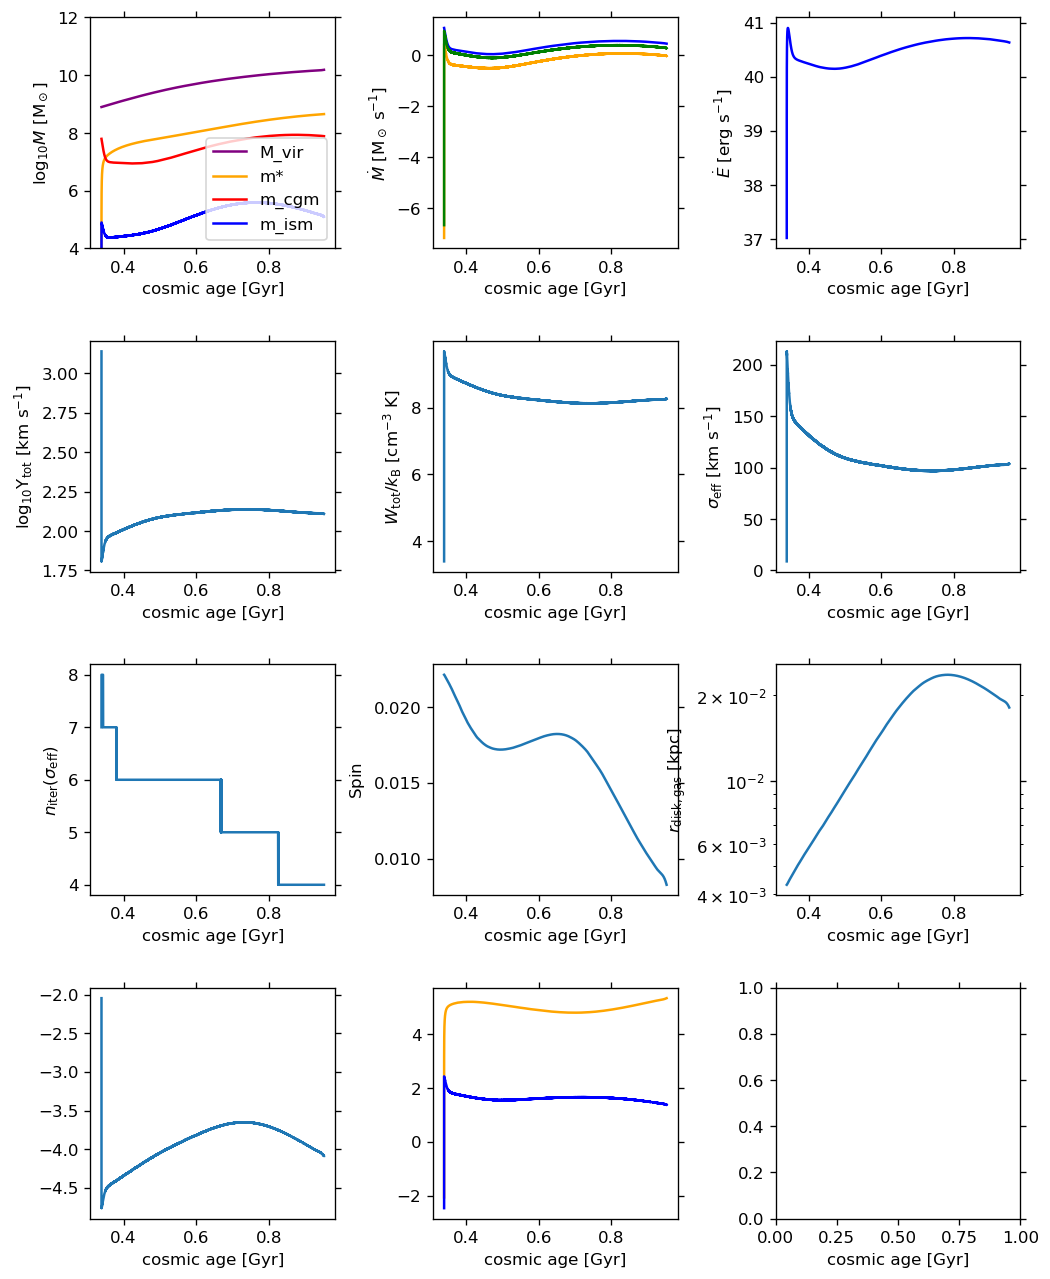

In [1233]:
fig, axes = plt.subplots(4, 3, figsize=(10, 13))

axes = np.array(axes).flatten()

axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mvir']), c='purple', label='M_vir')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_star']), c='orange', label='m*')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_cgm']), c='red', label='m_cgm')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_ism']), c='blue', label='m_ism')

axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_cool']), c='blue')
axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_sfr_longlived']), c='orange')
axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_wind']), c='green')
# axes[1].set_ylim(0, 3.5)


axes[2].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_cool']), c='blue')


[ax.set_xlabel('cosmic age [Gyr]') for ax in axes]
axes[0].set_ylabel(r'$\log_{10} M \ [{\rm M}_\odot]$')

axes[0].legend()

# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mvir']), c='purple', label='M_vir', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_star']), c='orange', label='m*', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_cgm']), c='red', label='m_cgm', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_ism']), c='blue', label='m_ism', ls='-.')

# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_cool']), c='blue', ls='-.')
# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_sfr_longlived']), c='orange', ls='-.')
# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_wind']), c='green', ls='-.')

# axes[2].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Edot_cool']), c='blue', ls='-.')

axes[3].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Up_tot']))
axes[3].set_ylabel(r'$\log_{10} \Upsilon_{\rm tot} \ [{\rm km} \ {\rm s}^{-1}]$')
# axes[3].set_ylim(2, 4)

axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['W4']))
axes[4].set_ylabel(r'$W_{\rm tot} / k_{\rm B} \ [{\rm cm}^{-3} \ {\rm K}]$')
# axes[4].set_ylim(0, 10)

axes[5].plot(comb_dict_PRFM['cosmic_age'], comb_dict_PRFM['sig_e'])
axes[5].set_ylabel(r'$ \sigma_{\rm eff} \ [{\rm km} \ {\rm s}^{-1}]$')
# axes[5].set_ylim(10, 80)

axes[6].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['n_iter']))
axes[6].set_ylabel(r'$n_{\rm iter}(\sigma_{\rm eff}) $')


axes[7].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Spin']))
axes[7].set_ylabel(r'${\rm Spin} $')


# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Rvir']), label='Rvir' )
# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(1/(2.)**(0.5) * np.array(comb_dict_PRFM['Rvir']) ))
# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Rvir']))
axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['r_disk_star']) * cm_to_kpc)
axes[8].set_yscale('log')
axes[8].set_ylabel(r'$r_{\rm disk, gas} \ [{\rm kpc}]$')

axes[9].plot(comb_dict_PRFM['cosmic_age'], np.array(np.log10(comb_dict_PRFM['tdep_ism'])))
# axes[9].plot(comb_dict_PRFM['cosmic_age'], np.array(np.log10(comb_dict['tdep_ism'])), ls='-.')


axes[10].plot(comb_dict_PRFM['cosmic_age'], (np.log10(np.array(comb_dict_PRFM['Sig_star']) * g_to_msun / (cm_to_pc)**2 ) ), c='orange')
axes[10].plot(comb_dict_PRFM['cosmic_age'], (np.log10(np.array(comb_dict_PRFM['Sig_gas']) * g_to_msun / (cm_to_pc)**2 ) ) , c='blue')

axes[0].set_ylim(4, 12)

axes[1].set_ylabel(r'$\dot{M} \ [{\rm M}_\odot \ {\rm s}^{-1}] $')
axes[2].set_ylabel(r'$\dot{E} \ [{\rm erg} \ {\rm s}^{-1}] $')


plt.subplots_adjust(wspace=0.4, hspace=0.4)

# [ax.set_xlim(0.205, 0.21) for ax in axes]

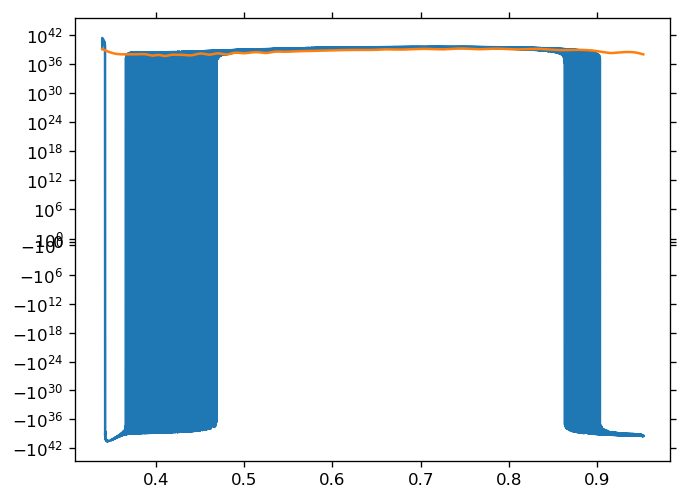

In [1234]:
plt.plot(comb_dict_PRFM['cosmic_age'], comb_dict_PRFM['Edot_cgm_th'])
plt.plot(comb_dict_PRFM['cosmic_age'], comb_dict_null['Edot_cgm_th'])
plt.yscale('symlog')
# plt.xlim(800, 1000)

(-0.1, 0.1)

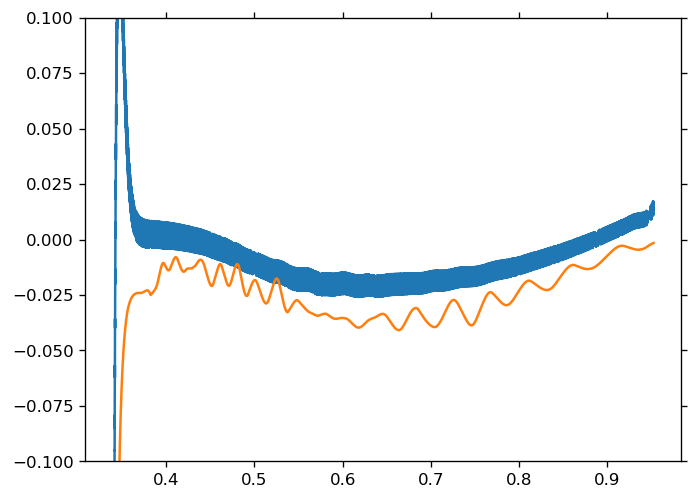

In [1235]:
plt.plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_cool'] + comb_dict_PRFM['Edot_out_halo']) - np.log10(comb_dict_PRFM['Edot_wind'] + comb_dict_PRFM['Edot_in_halo']))
plt.plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_cool'] + comb_dict_null['Edot_out_halo']) - np.log10(comb_dict_null['Edot_wind'] + comb_dict_null['Edot_in_halo']))

plt.ylim(-0.1, 0.1)

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/695026449.py:29: RuntimeWarning: divide by zero encountered in log10
  axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_out_halo']), c='black', label=r'$\dot{M}_{\rm out, halo}$')
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/695026449.py:30: RuntimeWarning: divide by zero encountered in log10
  axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_out_halo']), c='black', ls='--')
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/695026449.py:39: RuntimeWarning: divide by zero encountered in log10
  axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_out_halo']), c='black', label=r'$\dot{E}_{\rm out, halo}$')
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/695026449.py:40: RuntimeWarning: divide by zero encountered in log10
  axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_out_halo']), c=

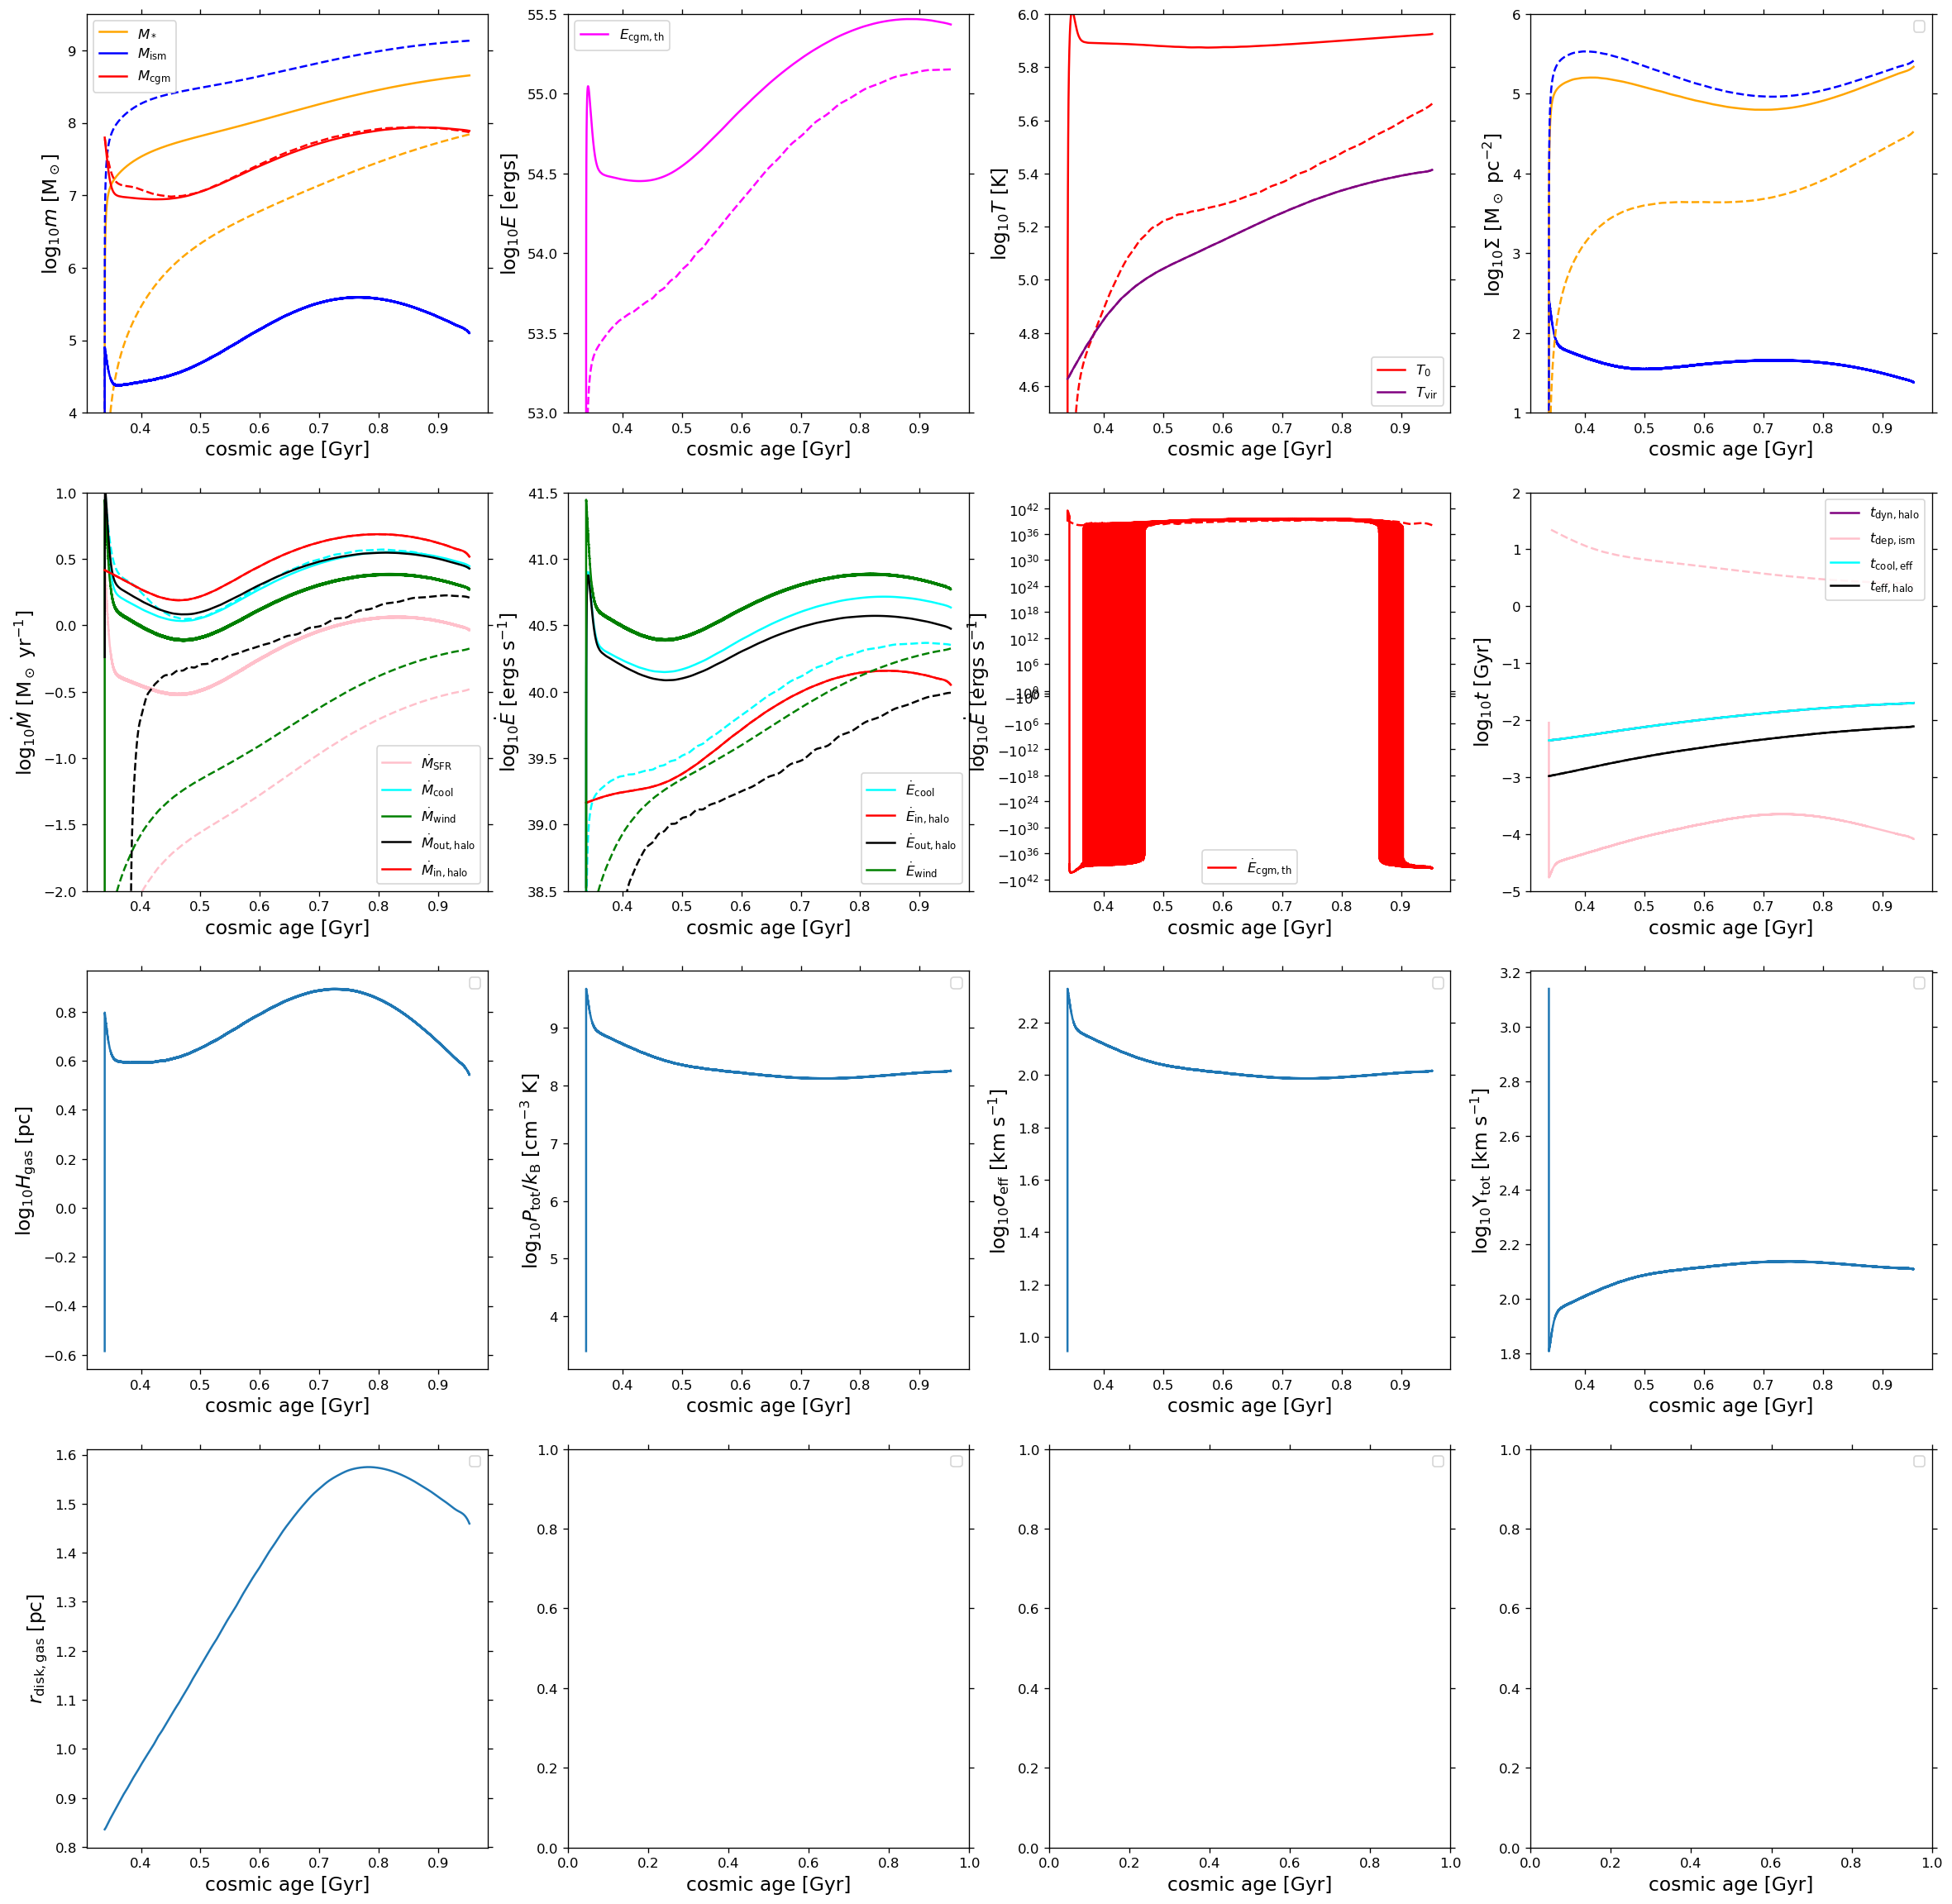

In [1249]:
fig, axes = plt.subplots(4, 4, figsize=(16*1.5, 16*1.5))

axes = np.array(axes).flatten()

axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_star']), c='orange', label=r'$M_{\rm *}$')
axes[0].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_star']), c='orange',  ls='--')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_ism']), c='blue', label=r'$M_{\rm ism}$')
axes[0].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_ism']), c='blue', ls='--')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_cgm']), c='red', label=r'$M_{\rm cgm}$')
axes[0].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_cgm']), c='red',  ls='--')
axes[0].set_ylim(4, 9.5)

axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Eth_cgm']), c='magenta', label=r'$E_{\rm cgm, th}$')
axes[1].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Eth_cgm']), c='magenta', ls='--')
axes[1].set_ylim(53, 55.5)

axes[2].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['T0_val']), c='red', label=r'$T_{\rm 0}$')
axes[2].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['T0_val']), c='red',  ls='--')
axes[2].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Tvir']), c='purple', label=r'$T_{\rm vir}$')
axes[2].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Tvir']), c='purple',  ls='--')
axes[2].set_ylim(4.5, 6)

axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_sfr_longlived']), c='pink', label=r'$\dot{M}_{\rm SFR}$')
axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_sfr_longlived']), c='pink', ls='--')
axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_cool']), c='cyan', label=r'$\dot{M}_{\rm cool}$')
axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_cool']), c='cyan', ls='--')
axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_wind']), c='green', label=r'$\dot{M}_{\rm wind}$')
axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_wind']), c='green', ls='--')
axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_out_halo']), c='black', label=r'$\dot{M}_{\rm out, halo}$')
axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_out_halo']), c='black', ls='--')
axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_in_halo']), c='red', label=r'$\dot{M}_{\rm in, halo}$')
axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_in_halo']), c='red', ls='--')
axes[4].set_ylim(-2, 1)

axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_cool']), c='cyan', label=r'$\dot{E}_{\rm cool}$')
axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_cool']), c='cyan', ls='--')
axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_in_halo']), c='red', label=r'$\dot{E}_{\rm in, halo}$')
axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_in_halo']), c='red', ls='--')
axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_out_halo']), c='black', label=r'$\dot{E}_{\rm out, halo}$')
axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_out_halo']), c='black', ls='--')
axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_wind']), c='green', label=r'$\dot{E}_{\rm wind}$')
axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Edot_wind']), c='green',  ls='--')
axes[5].set_ylim(38.5, 41.5)

axes[6].plot(comb_dict_PRFM['cosmic_age'], comb_dict_PRFM['Edot_cgm_th'], c='red', label=r'$\dot{E}_{\rm cgm, th}$')
axes[6].plot(comb_dict_PRFM['cosmic_age'], comb_dict_null['Edot_cgm_th'], c='red', ls='--')
axes[6].set_yscale('symlog')

axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['tdyn_halo']), c='purple', label=r'$t_{\rm dyn, halo}$')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['tdyn_halo']), c='purple', ls='--')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['tdep_ism']), c='pink', label=r'$t_{\rm dep, ism}$')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['tdep_ism']), c='pink', ls='--')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['tcool_eff']), c='cyan', label=r'$t_{\rm cool, eff}$')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['tcool_eff']), c='cyan', ls='--')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['tff_eff']), c='black', label=r'$t_{\rm eff, halo}$')
axes[7].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['tff_eff']), c='black', ls='--')
axes[7].set_ylim(-5, 2)
   
axes[3].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['Sig_gas'] * g_to_msun / (cm_to_kpc * 1e3)**2), c='blue')
axes[3].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['Sig_star'] * g_to_msun / (cm_to_kpc * 1e3)**2), c='orange')
axes[3].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Sig_gas'] * g_to_msun / (cm_to_kpc * 1e3)**2), c='blue', ls='--')
axes[3].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Sig_star'] * g_to_msun / (cm_to_kpc * 1e3)**2), c='orange', ls='--')
axes[3].set_ylim(1, 6)

axes[8].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['H'] * cm_to_kpc * 1e3))

axes[9].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['W4']))

axes[10].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['sig_e']))

axes[11].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Up_tot']))

axes[12].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['r_disk_gas'] * cm_to_kpc * 1e3 ))


_ = [ax.legend() for ax in axes]

_ = [ax.set_xlabel('cosmic age [Gyr]', fontsize=14) for ax in axes]
_ = axes[0].set_ylabel(r'$\log_{10} m \ [{\rm M}_\odot]$', fontsize=14)
_ = axes[1].set_ylabel(r'$\log_{10} E \ [{\rm ergs}]$', fontsize=14)
_ = axes[2].set_ylabel(r'$\log_{10} T \ [{\rm K}]$', fontsize=14)
_ = axes[3].set_ylabel(r'$\log_{10} \Sigma \ [{\rm M}_\odot \ {\rm pc}^{-2}]$', fontsize=14)
_ = axes[4].set_ylabel(r'$\log_{10} \dot{M} \ [{\rm M}_\odot \ {\rm yr}^{-1}]$', fontsize=14)
_ = axes[5].set_ylabel(r'$\log_{10} \dot{E} \ [{\rm ergs} \ {\rm s}^{-1}]$', fontsize=14)
_ = axes[6].set_ylabel(r'$\log_{10} \dot{E} \ [{\rm ergs} \ {\rm s}^{-1}]$', fontsize=14)
_ = axes[7].set_ylabel(r'$\log_{10} t \ [{\rm Gyr}]$', fontsize=14)
_ = axes[8].set_ylabel(r'$\log_{10} H_{\rm gas} \ [{\rm pc}]$', fontsize=14)
_ = axes[9].set_ylabel(r'$\log_{10} P_{\rm tot} / k_{\rm B} \ [{\rm cm}^{-3} \ {\rm K}]$', fontsize=14)
_ = axes[10].set_ylabel(r'$\log_{10} \sigma_{\rm eff} \ [{\rm km} \ {\rm s}^{-1}]$', fontsize=14)
_ = axes[11].set_ylabel(r'$\log_{10} \Upsilon_{\rm tot} \ [{\rm km} \ {\rm s}^{-1}]$', fontsize=14)
_ = axes[12].set_ylabel(r'$r_{\rm disk, gas} \ [{\rm pc}]$', fontsize=14)


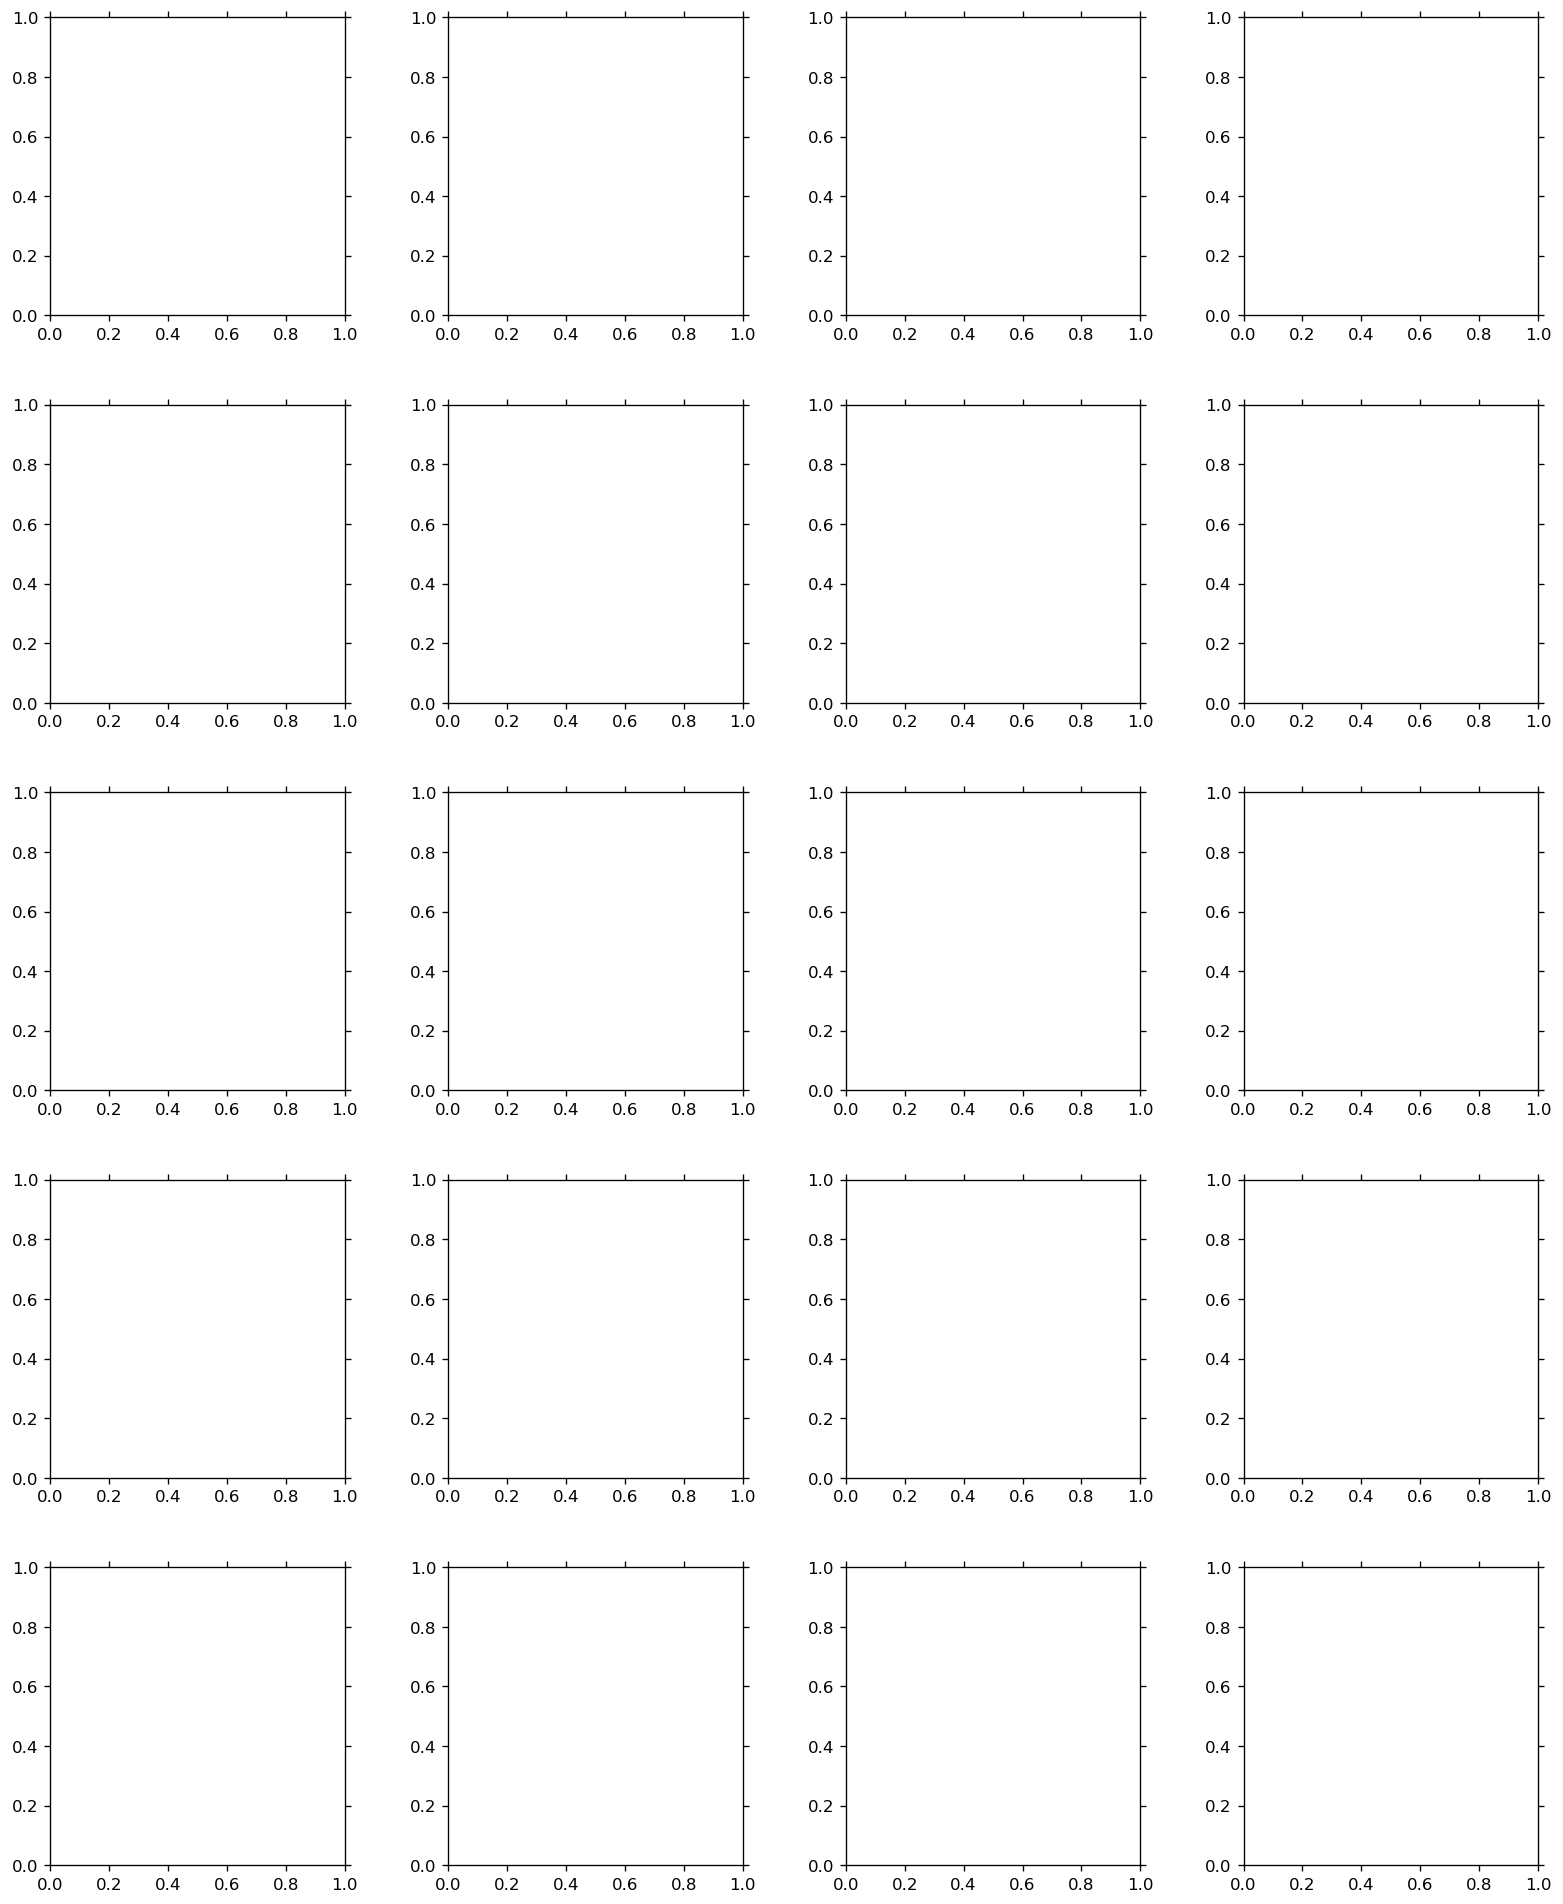

In [1237]:
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

axes = np.array(axes).flatten()






# axes[14].plot(comb_dict_null['cosmic_age'], 
#               np.log10(comb_dict_PRFM['Mdot_sfr_longlived'] / (2 * np.pi * (comb_dict_PRFM['r_disk_gas'] * cm_to_kpc )**2 )
#                       ))

# axes[15].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_PRFM['t_dyn'] * s_to_yr * 1e-9), label='m*')

# axes[2].set_ylim(7, 11)

# # 'tdep_ism': tdep_ism


# _ = [ax.set_xlim(0.18, comb_dict_PRFM['cosmic_age'][0]*1.05) for ax in axes]

# axes[0].set_ylim(0, 12)
# axes[1].set_ylim(0, 11)
# axes[2].set_ylim(6, 11)
# axes[3].set_ylim(0, 3)
# axes[4].set_ylim(-3, 3)
# axes[5].set_ylim(-0.5, 3.5)
# axes[6].set_ylim(-2.5, 3)
# axes[7].set_ylim(-0.5, 1)
# axes[8].set_ylim(1.8, 3)
# axes[9].set_ylim(8, 12)
# axes[10].set_ylim(1.2, 3.2)
# axes[11].set_ylim(-7, 2)
# axes[12].set_ylim(0, 3.4)
# axes[13].set_ylim(4, 8)
# axes[14].set_ylim(2, 6.5)
# axes[15].set_ylim(-5.5, -3.5)

plt.subplots_adjust(hspace=0.3, wspace=0.35)

In [ ]:
# fig, axes = plt.subplots(3, 4, figsize=(13, 10))

# axes = np.array(axes).flatten()

# axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_star']), c='orange', label='m*')
# axes[0].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_star']), c='orange', label='m*', ls='--')

# axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_ism']), c='blue', label='m*')
# axes[1].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_ism']), c='blue', label='m*', ls='--')


# axes[2].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_cgm']), c='red', label='m*')
# axes[2].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['M_cgm']), c='red', label='m*', ls='--')


# axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_sfr_longlived']), c='pink', label='m*')
# axes[4].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_sfr_longlived']), c='pink', label='m*', ls='--')


# axes[5].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_cool']), c='cyan', label='m*')
# axes[5].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_cool']), c='cyan', label='m*', ls='--')


# axes[6].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_wind']), c='green', label='m*')
# axes[6].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['Mdot_wind']), c='green', label='m*', ls='--')

# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['sig_e']), label='m*')


# axes[9].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['W4']), label='m*')

# axes[10].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Up_tot']), label='m*')


# axes[11].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['tdep_ism']), c='purple', label='m*')
# axes[11].plot(comb_dict_null['cosmic_age'], np.log10(comb_dict_null['tdep_ism']), c='purple', label='m*', ls='--')


# # axes[2].set_ylim(7, 11)

# _ = [ax.set_xlim(comb_dict_PRFM['cosmic_age'][-400]*(1 - 1e-5), comb_dict_PRFM['cosmic_age'][-2000]) for ax in axes]
# # 'tdep_ism': tdep_ism

In [636]:
parameters.update(return_all=False) 

res_null = [solve_system(halo_ids[i], parameters, integrator) for i in range(1000)]

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:17: RuntimeWarning: overflow encountered in scalar power
  M_star = 10**logy[0]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:21: RuntimeWarning: overflow encountered in scalar power
  MZ_star = 10**logy[4]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:113: RuntimeWarning: divide by zero encountered in log10
  halo_coolfunc = 10**rgi_sd93((np.log10(T0_val), log_Zcgm))
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:132: RuntimeWarning: invalid value encountered in scalar divide
  tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:164: RuntimeWarning: invalid value encountered in scalar divide
  Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/


 The solver successfully reached the end of the integration interval. solve_ivp took 0.067 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.034 seconds 



/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:219: RuntimeWarning: invalid value encountered in scalar multiply
  'Mdot_ism': Mdot_ism  / 10**logt * M_ism / s_to_yr,
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:87: RuntimeWarning: divide by zero encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:208: RuntimeWarning: divide by zero encountered in scalar divide
  MZdot_cgm *= 10**logt / MZ_cgm



 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.038 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.028 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.038 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.030 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.034 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.034 seconds 



/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:119: RuntimeWarning: overflow encountered in scalar multiply
  Sig_star = M_star * Msun_to_g / (2. * np.pi * r_disk_star**2) # g cm^-2


...


 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.034 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.043 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.032 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.037 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.036 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.037 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2413476107.py:203: RuntimeWarning: invalid value encountered in scalar multiply
  Mdot_ism *= 10**logt / M_ism



 The solver successfully reached the end of the integration interval. solve_ivp took 0.039 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.041 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.247 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.038 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.037 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.036 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.039 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t


 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.032 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.035 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.032 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.033 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.036 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.034 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.041 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.036 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t

KeyboardInterrupt: 

In [547]:
parameters.update(return_all=False) 

res_PRFM = [solve_system(halo_ids[i], parameters, integrator_PRFM) for i in range(1000)]

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:17: RuntimeWarning: overflow encountered in scalar power
  M_star = 10**logy[0]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:19: RuntimeWarning: overflow encountered in scalar power
  M_cgm = 10**logy[2]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:20: RuntimeWarning: overflow encountered in scalar power
  Eth_cgm = 10**logy[3]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:21: RuntimeWarning: overflow encountered in scalar power
  MZ_star = 10**logy[4]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:22: RuntimeWarning: overflow encountered in scalar power
  MZ_ism = 10**logy[5]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:23: RuntimeWarning: overflow encountered in scalar power
  MZ_cgm = 10**logy[6]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ip


 The solver successfully reached the end of the integration interval. solve_ivp took 0.896 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.324 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 5.485 seconds 



/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/3675938777.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  W = Sig_gas * (p1 + p2**(0.5)) / 4.
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_7058/2391116970.py:233: RuntimeWarning: divide by zero encountered in scalar divide
  Mdot_ism *= 10**logt / M_ism



 The solver successfully reached the end of the integration interval. solve_ivp took 4.564 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 5.270 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.461 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 4.210 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.657 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 5.571 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.219 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.490 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.174 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t


 The solver successfully reached the end of the integration interval. solve_ivp took 2.847 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 5.010 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.165 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.059 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.589 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 3.198 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.684 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.061 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.992 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t

...


 The solver successfully reached the end of the integration interval. solve_ivp took 1.000 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.653 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.051 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 4.648 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.724 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.683 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.656 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.595 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.796 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t


 The solver successfully reached the end of the integration interval. solve_ivp took 3.359 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.737 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.251 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.905 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.603 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.629 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.944 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.827 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.306 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t


 The solver successfully reached the end of the integration interval. solve_ivp took 1.448 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.831 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.586 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.580 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.852 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.335 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.293 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.803 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 3.175 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp t


 The solver successfully reached the end of the integration interval. solve_ivp took 0.758 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.989 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.568 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.819 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 40.297 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.821 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 5.595 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 4.879 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.507 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.071 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.778 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.829 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 1.818 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.847 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 0.466 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 12.418 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 2.091 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp took 3.602 seconds 


 The solver successfully reached the end of the integration interval. solve_ivp 

In [548]:
prfm_dict = {}
_ = [prfm_dict.update(res_PRFM[i]) for i in range(1000)]

null_dict = {}
_ = [null_dict.update(res_null[i]) for i in range(1000)]

In [549]:
import pandas as pd

In [550]:
idx_z_6 = np.argmin(abs(prfm_dict[halo_ids[0]]['redshift'] - 6))
idx_z_8 = np.argmin(abs(prfm_dict[halo_ids[0]]['redshift'] - 8))
idx_z_10 = np.argmin(abs(prfm_dict[halo_ids[0]]['redshift'] - 10))

In [551]:
def extract_redshifts(sol_dict, idx):
    halo_ids = list(sol_dict.keys())
    
    # generalize this to skip trees that dont have tht redshift index
    # have to unlist the comprehension 
    arr = np.array([[sol_dict[halo_ids[i]][key][idx] 
                     for key in sol_dict[halo_ids[i]].keys()] 
                    for i in range(len(halo_ids))])

    df = pd.DataFrame(arr, columns=sol_dict[halo_ids[0]].keys())

    return df

In [601]:
prfm_df_z_6 = extract_redshifts(prfm_dict, idx_z_6)
prfm_df_z_8 = extract_redshifts(prfm_dict, idx_z_8)

null_df_z_6 = extract_redshifts(null_dict, idx_z_6)
null_df_z_8 = extract_redshifts(null_dict, idx_z_8)

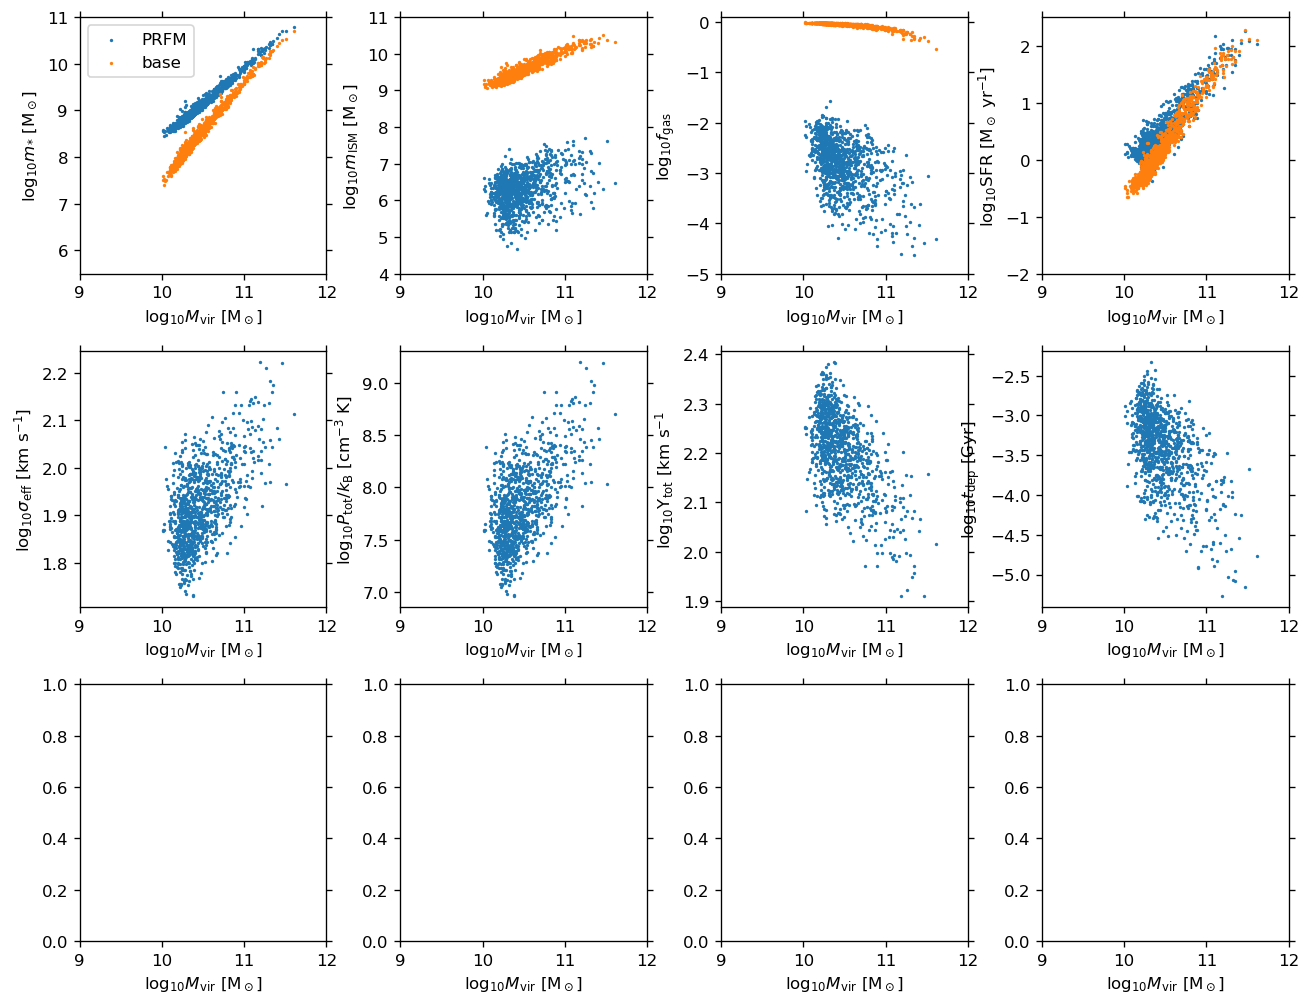

In [622]:


fig, axes = plt.subplots(3, 4, figsize=(13, 10))

axes = np.array(axes).flatten()

[axes[0].scatter(np.log10(df['Mvir']), np.log10(df['M_star']), s=1, label=lab) 
 for df, lab in zip([prfm_df_z_6, null_df_z_6], ['PRFM', 'base'])]
[axes[1].scatter(np.log10(df['Mvir']), np.log10(df['M_ism']), s=1) 
 for df in [prfm_df_z_6, null_df_z_6]]
[axes[2].scatter(np.log10(df['Mvir']), np.log10(df['M_ism'] / (df['M_ism'] + df['M_star'])), s=1) 
 for df in [prfm_df_z_6, null_df_z_6]]
[axes[3].scatter(np.log10(df['Mvir']), np.log10(df['Mdot_sfr_longlived']), s=1) 
 for df in [prfm_df_z_6, null_df_z_6]]
[axes[4].scatter(np.log10(df['Mvir']), np.log10(df['sig_e']), s=1) 
 for df in [prfm_df_z_6,]]
[axes[5].scatter(np.log10(df['Mvir']), np.log10(df['W4']), s=1) 
 for df in [prfm_df_z_6,]]
[axes[6].scatter(np.log10(df['Mvir']), np.log10(df['Up_tot']), s=1) 
 for df in [prfm_df_z_6,]]
[axes[7].scatter(np.log10(df['Mvir']), np.log10(df['tdep_ism']), s=1) 
 for df in [prfm_df_z_6,]]

_ = [ax.set_xlabel(r'$\log_{10} M_{\rm vir} \ [{\rm M}_\odot]$') for ax in axes]
axes[0].set_ylabel(r'$\log_{10} m_{*} \ [{\rm M}_\odot]$')
axes[1].set_ylabel(r'$\log_{10} m_{\rm ISM} \ [{\rm M}_\odot]$')
axes[2].set_ylabel(r'$\log_{10} f_{\rm gas} $')
axes[3].set_ylabel(r'$\log_{10} {\rm SFR}  \ [{\rm M}_\odot \ {\rm yr}^{-1}] $')
axes[4].set_ylabel(r'$\log_{10} \sigma_{\rm eff} \ [{\rm km} \ {\rm s}^{-1}] $')
axes[5].set_ylabel(r'$\log_{10} P_{\rm tot} / k_{\rm B} \ [{\rm cm}^{-3} \ {\rm K}] $')
axes[6].set_ylabel(r'$\log_{10} \Upsilon_{\rm tot}  \ [{\rm km} \ {\rm s}^{-1}$')
axes[7].set_ylabel(r'$\log_{10} t_{\rm dep} \ [{\rm Gyr}] $')

plt.subplots_adjust(wspace=0.3, hspace=0.3)

axes[0].legend() 

axes[0].set_ylim(5.5, 11)
axes[1].set_ylim(4, 11)
axes[2].set_ylim(-5, 0.1)
axes[3].set_ylim(-2, 2.5)
_ = [ax.set_xlim(9, 12) for ax in axes]


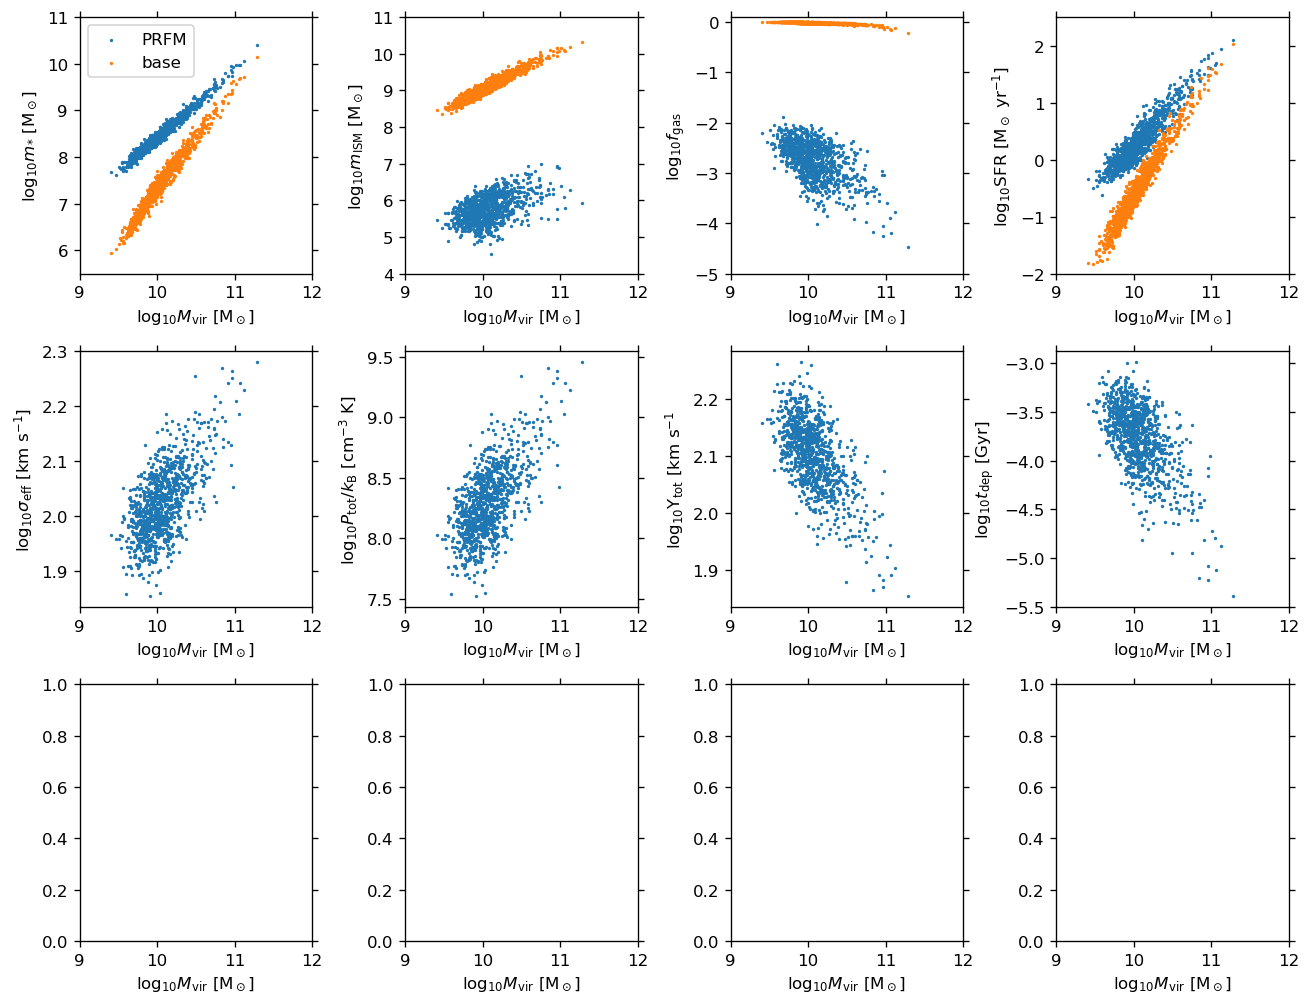

In [624]:

fig, axes = plt.subplots(3, 4, figsize=(13, 10))

axes = np.array(axes).flatten()

[axes[0].scatter(np.log10(df['Mvir']), np.log10(df['M_star']), s=1, label=lab) 
 for df, lab in zip([prfm_df_z_8, null_df_z_8], ['PRFM', 'base'])]
[axes[1].scatter(np.log10(df['Mvir']), np.log10(df['M_ism']), s=1) 
 for df in [prfm_df_z_8, null_df_z_8]]
[axes[2].scatter(np.log10(df['Mvir']), np.log10(df['M_ism'] / (df['M_ism'] + df['M_star'])), s=1) 
 for df in [prfm_df_z_8, null_df_z_8]]
[axes[3].scatter(np.log10(df['Mvir']), np.log10(df['Mdot_sfr_longlived']), s=1) 
 for df in [prfm_df_z_8, null_df_z_8]]
[axes[4].scatter(np.log10(df['Mvir']), np.log10(df['sig_e']), s=1) 
 for df in [prfm_df_z_8,]]
[axes[5].scatter(np.log10(df['Mvir']), np.log10(df['W4']), s=1) 
 for df in [prfm_df_z_8,]]
[axes[6].scatter(np.log10(df['Mvir']), np.log10(df['Up_tot']), s=1) 
 for df in [prfm_df_z_8,]]
[axes[7].scatter(np.log10(df['Mvir']), np.log10(df['tdep_ism']), s=1) 
 for df in [prfm_df_z_8,]]

_ = [ax.set_xlabel(r'$\log_{10} M_{\rm vir} \ [{\rm M}_\odot]$') for ax in axes]
axes[0].set_ylabel(r'$\log_{10} m_{*} \ [{\rm M}_\odot]$')
axes[1].set_ylabel(r'$\log_{10} m_{\rm ISM} \ [{\rm M}_\odot]$')
axes[2].set_ylabel(r'$\log_{10} f_{\rm gas} $')
axes[3].set_ylabel(r'$\log_{10} {\rm SFR}  \ [{\rm M}_\odot \ {\rm yr}^{-1}] $')
axes[4].set_ylabel(r'$\log_{10} \sigma_{\rm eff} \ [{\rm km} \ {\rm s}^{-1}] $')
axes[5].set_ylabel(r'$\log_{10} P_{\rm tot} / k_{\rm B} \ [{\rm cm}^{-3} \ {\rm K}] $')
axes[6].set_ylabel(r'$\log_{10} \Upsilon_{\rm tot}  \ [{\rm km} \ {\rm s}^{-1}$')
axes[7].set_ylabel(r'$\log_{10} t_{\rm dep} \ [{\rm Gyr}] $')

plt.subplots_adjust(wspace=0.4, hspace=0.3)

axes[0].legend() 

axes[0].set_ylim(5.5, 11)
axes[1].set_ylim(4, 11)
axes[2].set_ylim(-5, 0.1)
axes[3].set_ylim(-2, 2.5)
_ = [ax.set_xlim(9, 12) for ax in axes]

In [570]:
comb_dict_PRFM = prfm_dict[halo_ids[0]]

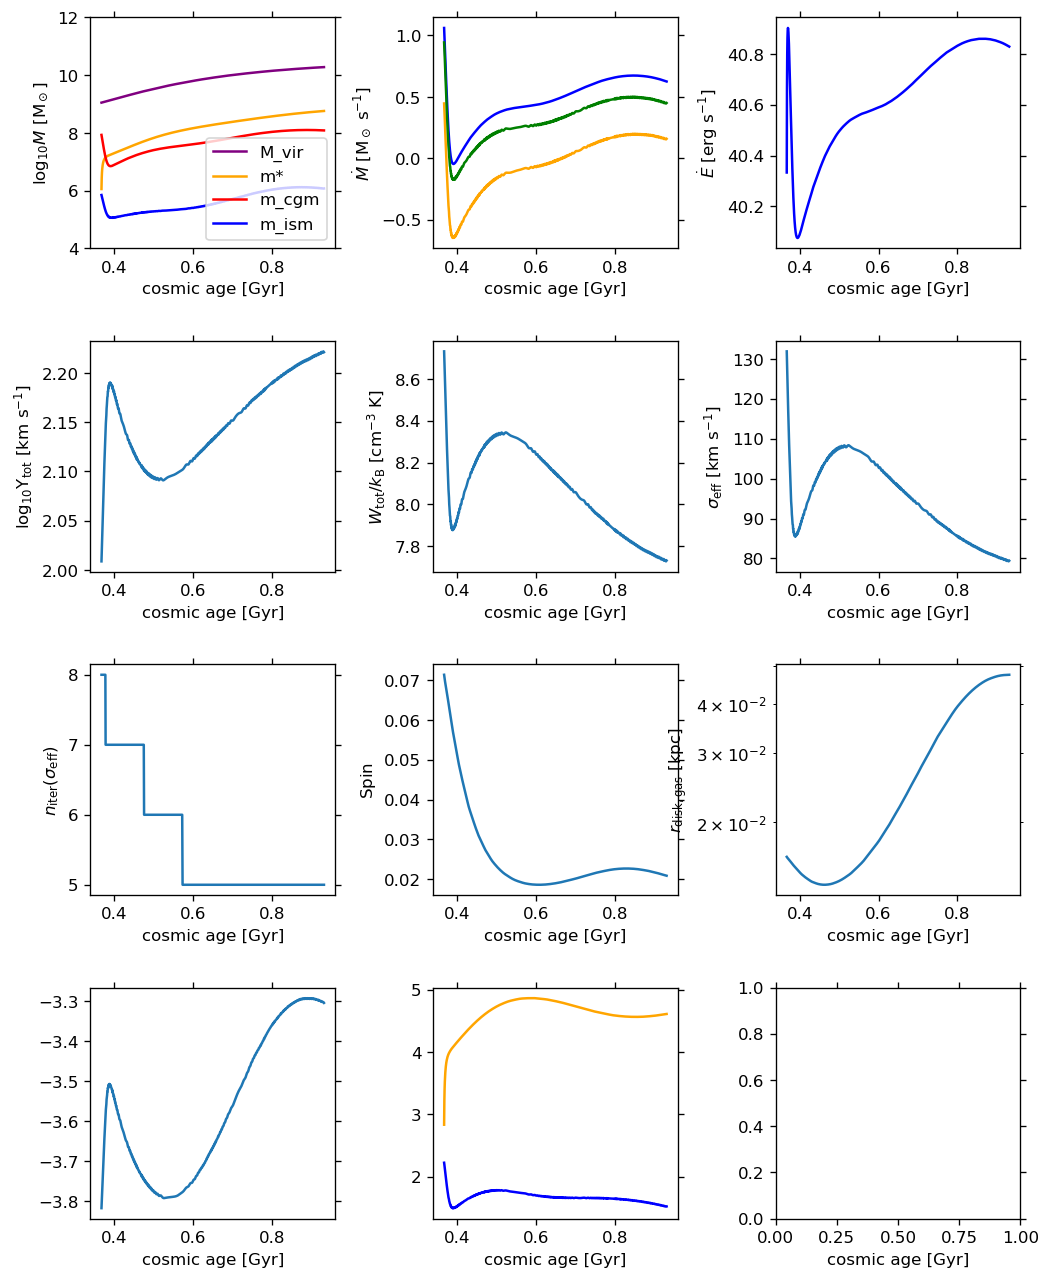

In [571]:
fig, axes = plt.subplots(4, 3, figsize=(10, 13))

axes = np.array(axes).flatten()

axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mvir']), c='purple', label='M_vir')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_star']), c='orange', label='m*')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_cgm']), c='red', label='m_cgm')
axes[0].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['M_ism']), c='blue', label='m_ism')

axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_cool']), c='blue')
axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_sfr_longlived']), c='orange')
axes[1].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Mdot_wind']), c='green')
# axes[1].set_ylim(0, 3.5)


axes[2].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Edot_cool']), c='blue')


[ax.set_xlabel('cosmic age [Gyr]') for ax in axes]
axes[0].set_ylabel(r'$\log_{10} M \ [{\rm M}_\odot]$')

axes[0].legend()

# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mvir']), c='purple', label='M_vir', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_star']), c='orange', label='m*', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_cgm']), c='red', label='m_cgm', ls='-.')
# axes[0].plot(comb_dict['cosmic_age'], np.log10(comb_dict['M_ism']), c='blue', label='m_ism', ls='-.')

# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_cool']), c='blue', ls='-.')
# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_sfr_longlived']), c='orange', ls='-.')
# axes[1].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Mdot_wind']), c='green', ls='-.')

# axes[2].plot(comb_dict['cosmic_age'], np.log10(comb_dict['Edot_cool']), c='blue', ls='-.')

axes[3].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['Up_tot']))
axes[3].set_ylabel(r'$\log_{10} \Upsilon_{\rm tot} \ [{\rm km} \ {\rm s}^{-1}]$')
# axes[3].set_ylim(2, 4)

axes[4].plot(comb_dict_PRFM['cosmic_age'], np.log10(comb_dict_PRFM['W4']))
axes[4].set_ylabel(r'$W_{\rm tot} / k_{\rm B} \ [{\rm cm}^{-3} \ {\rm K}]$')
# axes[4].set_ylim(0, 10)

axes[5].plot(comb_dict_PRFM['cosmic_age'], comb_dict_PRFM['sig_e'])
axes[5].set_ylabel(r'$ \sigma_{\rm eff} \ [{\rm km} \ {\rm s}^{-1}]$')
# axes[5].set_ylim(10, 80)

axes[6].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['n_iter']))
axes[6].set_ylabel(r'$n_{\rm iter}(\sigma_{\rm eff}) $')


axes[7].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Spin']))
axes[7].set_ylabel(r'${\rm Spin} $')


# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Rvir']), label='Rvir' )
# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(1/(2.)**(0.5) * np.array(comb_dict_PRFM['Rvir']) ))
# axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['Rvir']))
axes[8].plot(comb_dict_PRFM['cosmic_age'], np.array(comb_dict_PRFM['r_disk_star']) * cm_to_kpc)
axes[8].set_yscale('log')
axes[8].set_ylabel(r'$r_{\rm disk, gas} \ [{\rm kpc}]$')

axes[9].plot(comb_dict_PRFM['cosmic_age'], np.array(np.log10(comb_dict_PRFM['tdep_ism'])))
# axes[9].plot(comb_dict_PRFM['cosmic_age'], np.array(np.log10(comb_dict['tdep_ism'])), ls='-.')


axes[10].plot(comb_dict_PRFM['cosmic_age'], (np.log10(np.array(comb_dict_PRFM['Sig_star']) * g_to_msun / (cm_to_pc)**2 ) ), c='orange')
axes[10].plot(comb_dict_PRFM['cosmic_age'], (np.log10(np.array(comb_dict_PRFM['Sig_gas']) * g_to_msun / (cm_to_pc)**2 ) ) , c='blue')

axes[0].set_ylim(4, 12)

axes[1].set_ylabel(r'$\dot{M} \ [{\rm M}_\odot \ {\rm s}^{-1}] $')
axes[2].set_ylabel(r'$\dot{E} \ [{\rm erg} \ {\rm s}^{-1}] $')


plt.subplots_adjust(wspace=0.4, hspace=0.4)

# [ax.set_xlim(0.205, 0.21) for ax in axes]

In [572]:
prfm_df.keys()

Index(['sig_e', 'M_star', 'Mdot_cgm', 'Edot_cool', 'Mdot_wind', 'Mdot_in_halo',
       'Eth_cgm', 'n_iter', 'M_cgm', 'Tvir', 'Mdot_sfr_longlived',
       'Edot_in_halo', 'MZ_star', 'Sig_gas', 'M_ism', 'MZ_cgm', 'Edot_wind',
       'Spin', 'MZ_ism', 'T0_val', 'Mdot_out_halo', 'cosmic_age', 'Sig_star',
       'Mdot_cool', 'Mdot_ism', 'MZdot_star', 'Mvir', 'n0_val', 'redshift',
       'MZdot_ism', 'MZdot_cgm', 'Rvir', 'Edot_cgm_th', 'Up_tot', 'Mfilt',
       'r_disk_star', 'W4', 'Edot_out_halo', 'tdep_ism'],
      dtype='object')

In [557]:
null_df['M_star'] / prfm_df['M_star']

0      0.091874
1      0.254569
2      0.287268
3      0.125765
4      0.300892
         ...   
995    0.114751
996    0.162564
997    0.123324
998    0.161321
999    0.245713
Name: M_star, Length: 1000, dtype: float64